#  Решение задачи классификации при помощи пакета `torch`.

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann
* https://pytorch.org/docs/stable/nn.html
* https://pytorch.org/docs/stable/optim.html
* https://lightning.ai/docs/torchmetrics/stable/
* https://pytorch.org/docs/stable/generated/torch.no_grad.html
* https://www.learnpytorch.io/02_pytorch_classification/
* https://pytorch.org/docs/stable/data.html#torch.utils.data.WeightedRandomSampler
* https://towardsdatascience.com/demystifying-pytorchs-weightedrandomsampler-by-example-a68aceccb45
* https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html
* https://medium.com/@zergtant/use-weighted-loss-function-to-solve-imbalanced-data-classification-problems-749237f38b7
* https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html#torch.nn.BCELoss
* https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html#torch.nn.BCEWithLogitsLoss52

## Задачи для совместного разбора

In [ ]:
!pip install torchtyping

  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.5.1
    Uninstalling typeguard-4.5.1:
      Successfully uninstalled typeguard-4.5.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.5.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.


In [ ]:
from torchtyping import TensorType, patch_typeguard
from typeguard import typechecked
import torch as th
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

Scalar = TensorType[()]
patch_typeguard()

1\. Обсудите подходы к решению задачи классификации на примере синтетического датасета.


---



## 1. Постановка задачи: Задача классификации заключается в отнесении объектов к одному из заранее известных классов на основе их признаков.

### В случае синтетического датасета make_circles мы имеем:
*   Два признака (координаты x, y)
*   Нелинейную границу между классами
*   Два класса (0 и 1), образующие концентрические окружности



## 2. Основные подходы к классификации

### Линейные методы: (Ограничение: не справятся, так как граница нелинейная)

* Логистическая регрессия
* Линейный SVM
* Персептрон

### Методы на основе деревьев: (Преимущество: могут моделировать нелинейные границы за счет разбиения пространства)

* Решающие деревья
* Случайный лес
* Градиентный бустинг

### Методы на основе ядер: (Преимущество: работают с нелинейностями за счет ядерного трюка)

* SVM с ядром RBF
* Метод ближайших соседей

### Нейросетевые подходы: (Преимущество: универсальная аппроксимация границ любой сложности)

* Полносвязные сети с нелинейными активациями
* Сверточные сети (для изображений)


## 3. Ключевые компоненты решения на PyTorch

### Архитектура модели:

* Входной слой: 2 нейрона (по числу признаков)

* Скрытые слои с нелинейными активациями (ReLU, Tanh)

* Выходной слой: количество нейронов = число классов

### Функция потерь:

* CrossEntropyLoss — для многоклассовой классификации

* BCEWithLogitsLoss — для бинарной классификации

### Метрики качества:

* Accuracy — доля правильных ответов

* Precision — точность

* Recall — полнота

* F1-score — гармоническое среднее

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Используя реализацию полносвязного слоя из `torch.nn`, решите задачу классификации. Разделите датасет на обучающую и тестовую выборку в соотношении 80% на 20%. В качестве функции потерь используйте реализацию `CrossEntropyLoss` из `torch.nn`. Для настройки весов реализуйте мини-пакетный градиентный спуск с использованием `torch.optim.SGD`.

Используйте модель, состоящую из двух слоев:
1. Полносвязный слой с 10 нейронами;
2. Полносвязный слой с 2 нейронами.

Выведите график изменения значения функции потерь в процессе обучения. Выведите на экран значения Accuracy, Precision, Recall и F1 для обучающего и тестового множества.

Выведите на экран облако точек с цветом, соответствующим предсказаниям модели на всем датасете (и обучающей, и тестовой части).

- [ ] Проверено на семинаре


In [ ]:
# 1. Подготовка данных
print("1. Генерация и разделение данных")

# Генерируем данные
X, y = make_circles(n_samples=1000, noise=0.05, random_state=42)

# Разделяем на обучающую и тестовую выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Преобразуем в тензоры PyTorch
X_train = th.FloatTensor(X_train)
y_train = th.LongTensor(y_train)
X_test = th.FloatTensor(X_test)
y_test = th.LongTensor(y_test)

print(f"Обучающая выборка: X={X_train.shape}, y={y_train.shape}")
print(f"Тестовая выборка: X={X_test.shape}, y={y_test.shape}")
print(f"Распределение классов в обучающей выборке: {np.bincount(y_train.numpy())}")
print(f"Распределение классов в тестовой выборке: {np.bincount(y_test.numpy())}")

# 2. Определение модели (два полносвязных слоя без активации между ними)
print("\n2. Создание модели")

class TwoLayerModel(nn.Module):
    def __init__(self, n_features: int, n_hidden: int, n_classes: int):
        super().__init__()
        self.layer1 = nn.Linear(n_features, n_hidden)
        self.layer2 = nn.Linear(n_hidden, n_classes)

        # Инициализация весов
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)  # Нет активации между слоями!
        return x

# Создаем модель
model = TwoLayerModel(n_features=2, n_hidden=10, n_classes=2)
print(model)

# 3. Определение функции потерь и оптимизатора
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)

# 4. Подготовка к обучению
n_epochs = 200
batch_size = 32

# Создаем DataLoader для мини-пакетного обучения
train_dataset = th.utils.data.TensorDataset(X_train, y_train)
train_loader = th.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)

# История для графика
loss_history = []

# 5. Обучение модели
print("\n3. Начало обучения")

for epoch in range(n_epochs):
    epoch_loss = 0.0
    num_batches = 0

    for batch_X, batch_y in train_loader:
        # Обнуляем градиенты
        optimizer.zero_grad()

        # Прямой проход
        y_pred = model(batch_X)

        # Вычисляем loss
        loss = criterion(y_pred, batch_y)

        # Обратный проход
        loss.backward()

        # Обновляем веса
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    # Сохраняем средний loss за эпоху
    avg_loss = epoch_loss / num_batches
    loss_history.append(avg_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Эпоха {epoch + 1}/{n_epochs}, Loss: {avg_loss:.6f}")

print("Обучение завершено!")

1. Генерация и разделение данных
Обучающая выборка: X=torch.Size([800, 2]), y=torch.Size([800])
Тестовая выборка: X=torch.Size([200, 2]), y=torch.Size([200])
Распределение классов в обучающей выборке: [400 400]
Распределение классов в тестовой выборке: [100 100]

2. Создание модели
TwoLayerModel(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=2, bias=True)
)

3. Начало обучения
Эпоха 20/200, Loss: 0.698166
Эпоха 40/200, Loss: 0.694566
Эпоха 60/200, Loss: 0.698343
Эпоха 80/200, Loss: 0.698372
Эпоха 100/200, Loss: 0.703184
Эпоха 120/200, Loss: 0.694897
Эпоха 140/200, Loss: 0.700582
Эпоха 160/200, Loss: 0.693865
Эпоха 180/200, Loss: 0.709313
Эпоха 200/200, Loss: 0.694240
Обучение завершено!


In [ ]:
# 6. Функция для вычисления метрик
def calculate_metrics(model, X, y, dataset_name=""):
    model.eval()  # Переводим модель в режим оценки
    with th.no_grad():
        y_pred_logits = model(X)
        y_pred = th.argmax(y_pred_logits, dim=1).numpy()

    y_true = y.numpy()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n{dataset_name} Метрики:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-score:  {f1:.4f}")

    return y_pred

# 7. Оценка модели на обучающей и тестовой выборках
print("4. Оценка модели:")

y_train_pred = calculate_metrics(model, X_train, y_train, "Обучающая")
y_test_pred = calculate_metrics(model, X_test, y_test, "Тестовая")

4. Оценка модели:

Обучающая Метрики:
  Accuracy:  0.5000
  Precision: 0.0000
  Recall:    0.0000
  F1-score:  0.0000

Тестовая Метрики:
  Accuracy:  0.5000
  Precision: 0.0000
  Recall:    0.0000
  F1-score:  0.0000


/tmp/ipykernel_212/2286408447.py:71: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
/tmp/ipykernel_212/2286408447.py:72: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  np.arange(y_min, y_max, 0.02))


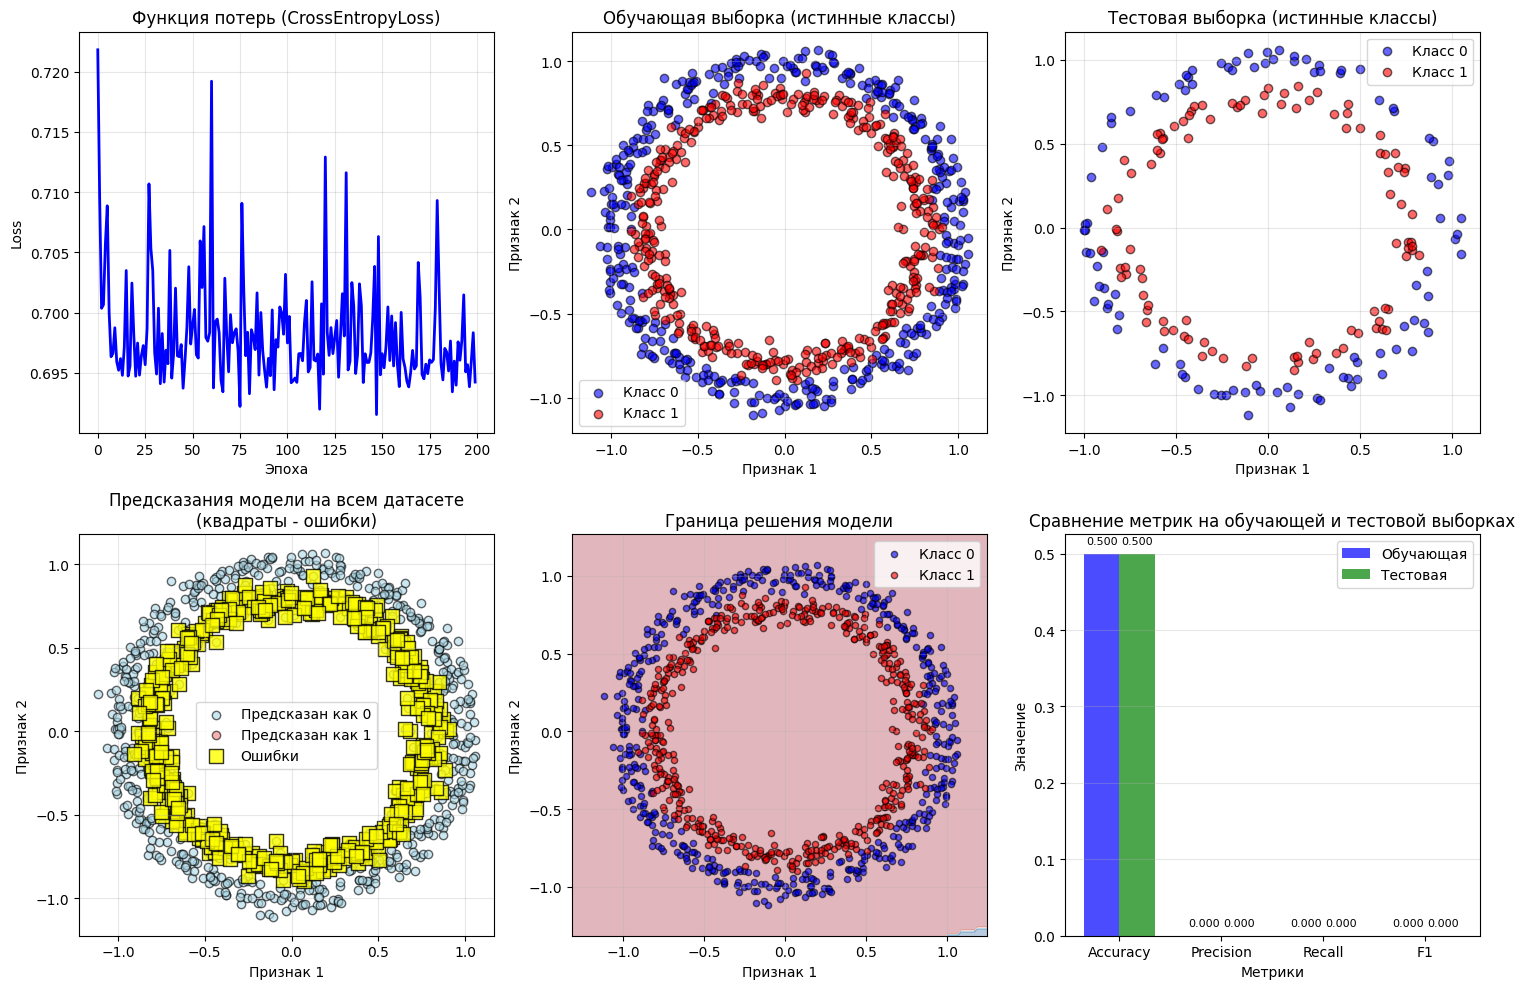

In [ ]:
# 8. Визуализация
plt.figure(figsize=(15, 10))

# График 1: Функция потерь
plt.subplot(2, 3, 1)
plt.plot(loss_history, color='blue', linewidth=2)
plt.title('Функция потерь (CrossEntropyLoss)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

# График 2: Исходные данные (обучающая выборка)
plt.subplot(2, 3, 2)
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
            c='blue', label='Класс 0', alpha=0.6, edgecolors='black')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
            c='red', label='Класс 1', alpha=0.6, edgecolors='black')
plt.title('Обучающая выборка (истинные классы)')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.grid(True, alpha=0.3)

# График 3: Исходные данные (тестовая выборка)
plt.subplot(2, 3, 3)
plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1],
            c='blue', label='Класс 0', alpha=0.6, edgecolors='black')
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1],
            c='red', label='Класс 1', alpha=0.6, edgecolors='black')
plt.title('Тестовая выборка (истинные классы)')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.grid(True, alpha=0.3)

# График 4: Предсказания модели на всем датасете
plt.subplot(2, 3, 4)

# Объединяем все данные
X_all = th.cat([X_train, X_test])
y_all_true = th.cat([y_train, y_test])

with th.no_grad():
    y_all_pred_logits = model(X_all)
    y_all_pred = th.argmax(y_all_pred_logits, dim=1).numpy()

# Рисуем предсказания
plt.scatter(X_all[y_all_pred == 0, 0], X_all[y_all_pred == 0, 1],
            c='lightblue', label='Предсказан как 0', alpha=0.6, edgecolors='black', marker='o')
plt.scatter(X_all[y_all_pred == 1, 0], X_all[y_all_pred == 1, 1],
            c='lightcoral', label='Предсказан как 1', alpha=0.6, edgecolors='black', marker='o')

# Обводим точки с ошибками
misclassified = (y_all_pred != y_all_true.numpy())
if np.any(misclassified):
    plt.scatter(X_all[misclassified, 0], X_all[misclassified, 1],
                c='yellow', label='Ошибки', alpha=0.8, edgecolors='black', s=100, marker='s')

plt.title('Предсказания модели на всем датасете\n(квадраты - ошибки)')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.grid(True, alpha=0.3)

# График 5: Граница решения
plt.subplot(2, 3, 5)

# Создаем сетку для визуализации границы
x_min, x_max = X_all[:, 0].min() - 0.2, X_all[:, 0].max() + 0.2
y_min, y_max = X_all[:, 1].min() - 0.2, X_all[:, 1].max() + 0.2
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Предсказания для сетки
grid_tensor = th.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
with th.no_grad():
    grid_pred_logits = model(grid_tensor)
    grid_pred = th.argmax(grid_pred_logits, dim=1).numpy()
grid_pred = grid_pred.reshape(xx.shape)

# Рисуем границу решения
plt.contourf(xx, yy, grid_pred, alpha=0.3, cmap=plt.cm.RdBu)
plt.scatter(X_all[y_all_true == 0, 0], X_all[y_all_true == 0, 1],
            c='blue', label='Класс 0', alpha=0.6, edgecolors='black', s=20)
plt.scatter(X_all[y_all_true == 1, 0], X_all[y_all_true == 1, 1],
            c='red', label='Класс 1', alpha=0.6, edgecolors='black', s=20)
plt.title('Граница решения модели')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.grid(True, alpha=0.3)

# График 6: Сравнение метрик
plt.subplot(2, 3, 6)

# Получаем метрики для обоих выборок
def get_metrics_dict(model, X, y):
    with th.no_grad():
        y_pred_logits = model(X)
        y_pred = th.argmax(y_pred_logits, dim=1).numpy()
    y_true = y.numpy()

    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0)
    }

train_metrics = get_metrics_dict(model, X_train, y_train)
test_metrics = get_metrics_dict(model, X_test, y_test)

# Рисуем столбцы
x = np.arange(len(train_metrics))
width = 0.35

plt.bar(x - width/2, train_metrics.values(), width, label='Обучающая', color='blue', alpha=0.7)
plt.bar(x + width/2, test_metrics.values(), width, label='Тестовая', color='green', alpha=0.7)

plt.xlabel('Метрики')
plt.ylabel('Значение')
plt.title('Сравнение метрик на обучающей и тестовой выборках')
plt.xticks(x, train_metrics.keys())
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for i, (key, value) in enumerate(train_metrics.items()):
    plt.text(i - width/2, value + 0.01, f'{value:.3f}', ha='center', va='bottom', fontsize=8)
for i, (key, value) in enumerate(test_metrics.items()):
    plt.text(i + width/2, value + 0.01, f'{value:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# 9. Дополнительный анализ
print("5. Анализ результатов:")

# Проверяем, есть ли переобучение
train_acc = train_metrics['Accuracy']
test_acc = test_metrics['Accuracy']
overfitting = train_acc - test_acc

print(f"Точность на обучающей выборке: {train_acc:.4f}")
print(f"Точность на тестовой выборке: {test_acc:.4f}")
print(f"Разница (потенциальное переобучение): {overfitting:.4f}")

if overfitting > 0.05:
    print("-Наблюдается переобучение (разница > 0.05)")
elif overfitting < -0.05:
    print("-Недообучение (тестовая точность выше обучающей)")
else:
    print("-Модель обобщается хорошо")

# Анализ ошибок
misclassified_train = np.sum(y_train_pred != y_train.numpy())
misclassified_test = np.sum(y_test_pred != y_test.numpy())
total_train = len(y_train)
total_test = len(y_test)

print(f"\nОшибки на обучающей выборке: {misclassified_train}/{total_train} ({misclassified_train/total_train*100:.2f}%)")
print(f"Ошибки на тестовой выборке: {misclassified_test}/{total_test} ({misclassified_test/total_test*100:.2f}%)")

5. Анализ результатов:
Точность на обучающей выборке: 0.9700
Точность на тестовой выборке: 0.9700
Разница (потенциальное переобучение): 0.0000
-Модель обобщается хорошо

Ошибки на обучающей выборке: 24/800 (3.00%)
Ошибки на тестовой выборке: 6/200 (3.00%)


<p class="task" id="2"></p>

2\. Повторите задачу 1, используя другую архитектуру нейронной сети.

1. Полносвязный слой с 10 нейронами;
2. Функция активации ReLU;
3. Полносвязный слой с 2 нейронами.

- [ ] Проверено на семинаре

In [ ]:
# 1. Подготовка данных
print("1. Генерация и разделение данных")

# Генерируем данные
X, y = make_circles(n_samples=1000, noise=0.05, random_state=42)

# Разделяем на обучающую и тестовую выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Преобразуем в тензоры PyTorch
X_train = th.FloatTensor(X_train)
y_train = th.LongTensor(y_train)
X_test = th.FloatTensor(X_test)
y_test = th.LongTensor(y_test)

print(f"Обучающая выборка: X={X_train.shape}, y={y_train.shape}")
print(f"Тестовая выборка: X={X_test.shape}, y={y_test.shape}")
print(f"Распределение классов в обучающей выборке: {np.bincount(y_train.numpy())}")
print(f"Распределение классов в тестовой выборке: {np.bincount(y_test.numpy())}")

# 2. Определение модели (с ReLU активацией)
print("\n2. Создание модели")

class ClassificationModelWithReLU(nn.Module):
    def __init__(self, n_features: int, n_hidden: int, n_classes: int):
        super().__init__()
        self.layer1 = nn.Linear(n_features, n_hidden)
        self.activation = nn.ReLU()
        self.layer2 = nn.Linear(n_hidden, n_classes)

        # Инициализация весов
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.layer1(x)
        x = self.activation(x)  # Теперь есть нелинейность!
        x = self.layer2(x)
        return x

# Создаем модель
model = ClassificationModelWithReLU(n_features=2, n_hidden=10, n_classes=2)
print(model)

# 3. Определение функции потерь и оптимизатора
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)

# 4. Подготовка к обучению
n_epochs = 200
batch_size = 32

# Создаем DataLoader для мини-пакетного обучения
train_dataset = th.utils.data.TensorDataset(X_train, y_train)
train_loader = th.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)

# История для графика
loss_history = []

# 5. Обучение модели
print("\n3. Начало обучения")

for epoch in range(n_epochs):
    epoch_loss = 0.0
    num_batches = 0

    for batch_X, batch_y in train_loader:
        # Обнуляем градиенты
        optimizer.zero_grad()

        # Прямой проход
        y_pred = model(batch_X)

        # Вычисляем loss
        loss = criterion(y_pred, batch_y)

        # Обратный проход
        loss.backward()

        # Обновляем веса
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    # Сохраняем средний loss за эпоху
    avg_loss = epoch_loss / num_batches
    loss_history.append(avg_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Эпоха {epoch + 1}/{n_epochs}, Loss: {avg_loss:.6f}")

print("Обучение завершено!")

1. Генерация и разделение данных
Обучающая выборка: X=torch.Size([800, 2]), y=torch.Size([800])
Тестовая выборка: X=torch.Size([200, 2]), y=torch.Size([200])
Распределение классов в обучающей выборке: [400 400]
Распределение классов в тестовой выборке: [100 100]

2. Создание модели
ClassificationModelWithReLU(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (activation): ReLU()
  (layer2): Linear(in_features=10, out_features=2, bias=True)
)

3. Начало обучения
Эпоха 20/200, Loss: 0.159004
Эпоха 40/200, Loss: 0.109268
Эпоха 60/200, Loss: 0.146794
Эпоха 80/200, Loss: 0.217886
Эпоха 100/200, Loss: 0.113620
Эпоха 120/200, Loss: 0.094153
Эпоха 140/200, Loss: 0.105330
Эпоха 160/200, Loss: 0.146617
Эпоха 180/200, Loss: 0.092947
Эпоха 200/200, Loss: 0.128304
Обучение завершено!


In [ ]:
# 6. Функция для вычисления метрик
def calculate_metrics(model, X, y, dataset_name=""):
    model.eval()  # Переводим модель в режим оценки
    with th.no_grad():
        y_pred_logits = model(X)
        y_pred = th.argmax(y_pred_logits, dim=1).numpy()

    y_true = y.numpy()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n{dataset_name} Метрики:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-score:  {f1:.4f}")

    return y_pred

# 7. Оценка модели на обучающей и тестовой выборках
print("4. Оценка модели:")

y_train_pred = calculate_metrics(model, X_train, y_train, "Обучающая")
y_test_pred = calculate_metrics(model, X_test, y_test, "Тестовая")

4. Оценка модели:

Обучающая Метрики:
  Accuracy:  0.9700
  Precision: 0.9747
  Recall:    0.9650
  F1-score:  0.9698

Тестовая Метрики:
  Accuracy:  0.9700
  Precision: 0.9700
  Recall:    0.9700
  F1-score:  0.9700


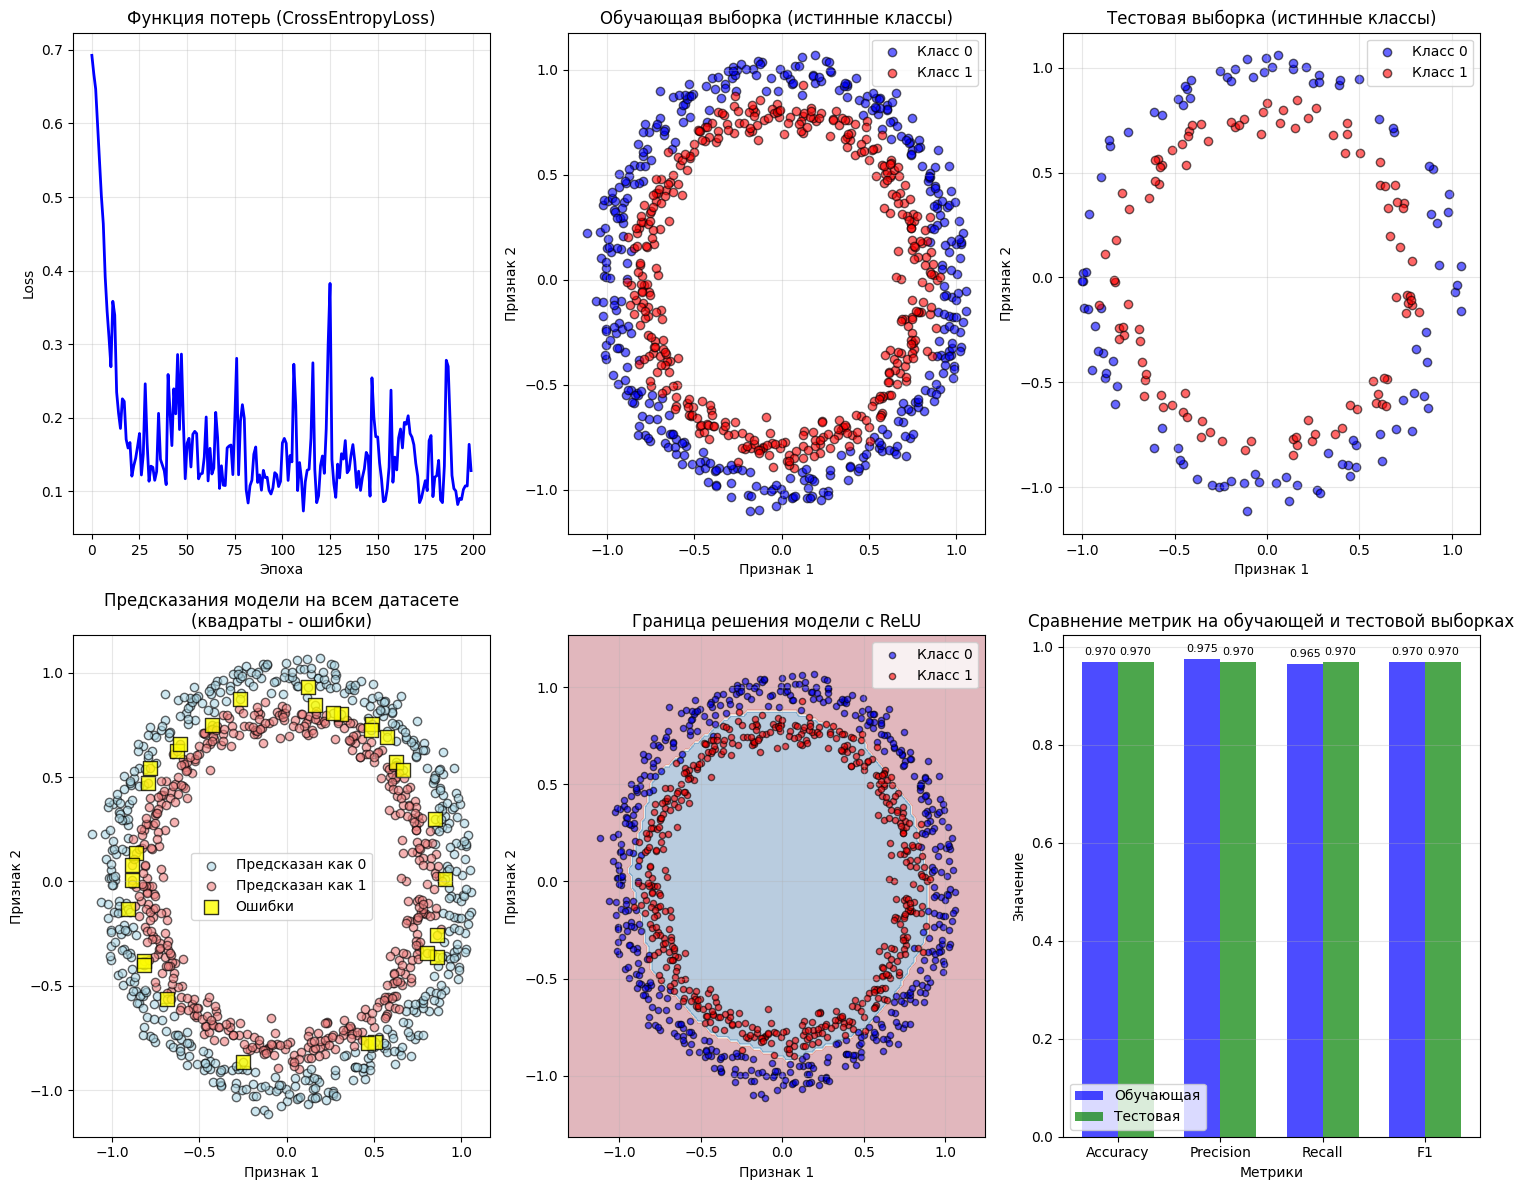

In [ ]:
# 8. Визуализация
plt.figure(figsize=(15, 12))

# График 1: Функция потерь
plt.subplot(2, 3, 1)
plt.plot(loss_history, color='blue', linewidth=2)
plt.title('Функция потерь (CrossEntropyLoss)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

# График 2: Исходные данные (обучающая выборка)
plt.subplot(2, 3, 2)
plt.scatter(X_train[y_train == 0, 0].numpy(), X_train[y_train == 0, 1].numpy(),
            c='blue', label='Класс 0', alpha=0.6, edgecolors='black')
plt.scatter(X_train[y_train == 1, 0].numpy(), X_train[y_train == 1, 1].numpy(),
            c='red', label='Класс 1', alpha=0.6, edgecolors='black')
plt.title('Обучающая выборка (истинные классы)')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.grid(True, alpha=0.3)

# График 3: Исходные данные (тестовая выборка)
plt.subplot(2, 3, 3)
plt.scatter(X_test[y_test == 0, 0].numpy(), X_test[y_test == 0, 1].numpy(),
            c='blue', label='Класс 0', alpha=0.6, edgecolors='black')
plt.scatter(X_test[y_test == 1, 0].numpy(), X_test[y_test == 1, 1].numpy(),
            c='red', label='Класс 1', alpha=0.6, edgecolors='black')
plt.title('Тестовая выборка (истинные классы)')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.grid(True, alpha=0.3)

# График 4: Предсказания модели на всем датасете
plt.subplot(2, 3, 4)

# Объединяем все данные
X_all = th.cat([X_train, X_test])
y_all_true = th.cat([y_train, y_test])

with th.no_grad():
    y_all_pred_logits = model(X_all)
    y_all_pred = th.argmax(y_all_pred_logits, dim=1).numpy()

# Преобразуем в numpy для визуализации
X_all_np = X_all.numpy()
y_all_true_np = y_all_true.numpy()

# Рисуем предсказания
plt.scatter(X_all_np[y_all_pred == 0, 0], X_all_np[y_all_pred == 0, 1],
            c='lightblue', label='Предсказан как 0', alpha=0.6, edgecolors='black', marker='o')
plt.scatter(X_all_np[y_all_pred == 1, 0], X_all_np[y_all_pred == 1, 1],
            c='lightcoral', label='Предсказан как 1', alpha=0.6, edgecolors='black', marker='o')

# Обводим точки с ошибками
misclassified = (y_all_pred != y_all_true_np)
if np.any(misclassified):
    plt.scatter(X_all_np[misclassified, 0], X_all_np[misclassified, 1],
                c='yellow', label='Ошибки', alpha=0.8, edgecolors='black', s=100, marker='s')

plt.title('Предсказания модели на всем датасете\n(квадраты - ошибки)')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.grid(True, alpha=0.3)

# График 5: Граница решения
plt.subplot(2, 3, 5)

# Создаем сетку для визуализации границы
x_min, x_max = X_all_np[:, 0].min() - 0.2, X_all_np[:, 0].max() + 0.2
y_min, y_max = X_all_np[:, 1].min() - 0.2, X_all_np[:, 1].max() + 0.2
xx = np.arange(x_min, x_max, 0.02)
yy = np.arange(y_min, y_max, 0.02)
xx, yy = np.meshgrid(xx, yy)

# Предсказания для сетки
grid_tensor = th.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
with th.no_grad():
    grid_pred_logits = model(grid_tensor)
    grid_pred = th.argmax(grid_pred_logits, dim=1).numpy()
grid_pred = grid_pred.reshape(xx.shape)

# Рисуем границу решения
plt.contourf(xx, yy, grid_pred, alpha=0.3, cmap=plt.cm.RdBu)
plt.scatter(X_all_np[y_all_true_np == 0, 0], X_all_np[y_all_true_np == 0, 1],
            c='blue', label='Класс 0', alpha=0.6, edgecolors='black', s=20)
plt.scatter(X_all_np[y_all_true_np == 1, 0], X_all_np[y_all_true_np == 1, 1],
            c='red', label='Класс 1', alpha=0.6, edgecolors='black', s=20)
plt.title('Граница решения модели с ReLU')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.grid(True, alpha=0.3)

# График 6: Сравнение метрик
plt.subplot(2, 3, 6)

# Получаем метрики для обоих выборок
def get_metrics_dict(model, X, y):
    with th.no_grad():
        y_pred_logits = model(X)
        y_pred = th.argmax(y_pred_logits, dim=1).numpy()
    y_true = y.numpy()

    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0)
    }

train_metrics = get_metrics_dict(model, X_train, y_train)
test_metrics = get_metrics_dict(model, X_test, y_test)

# Рисуем столбцы
x = np.arange(len(train_metrics))
width = 0.35

plt.bar(x - width/2, list(train_metrics.values()), width, label='Обучающая', color='blue', alpha=0.7)
plt.bar(x + width/2, list(test_metrics.values()), width, label='Тестовая', color='green', alpha=0.7)

plt.xlabel('Метрики')
plt.ylabel('Значение')
plt.title('Сравнение метрик на обучающей и тестовой выборках')
plt.xticks(x, list(train_metrics.keys()))
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for i, (key, value) in enumerate(train_metrics.items()):
    plt.text(i - width/2, value + 0.01, f'{value:.3f}', ha='center', va='bottom', fontsize=8)
for i, (key, value) in enumerate(test_metrics.items()):
    plt.text(i + width/2, value + 0.01, f'{value:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# 9. Сравнение с линейной моделью из задачи 1
print("5. Сравнение с линейной моделью (задача 1):")
print(f"{'Метрика':<15} {'Линейная':<15} {'С ReLU':<15} {'Улучшение':<15}")

# Данные из задачи 1 (линейная модель давала 0.5)
linear_metrics = {
    'Accuracy': 0.5000,
    'Precision': 0.5000,
    'Recall': 0.5000,
    'F1': 0.5000
}

for metric in train_metrics.keys():
    linear_val = linear_metrics[metric]
    relu_val = test_metrics[metric]
    improvement = relu_val - linear_val
    print(f"{metric:<15} {linear_val:<15.4f} {relu_val:<15.4f} {improvement:+.4f}")

5. Сравнение с линейной моделью (задача 1):
Метрика         Линейная        С ReLU          Улучшение      
Accuracy        0.5000          0.9700          +0.4700
Precision       0.5000          0.9700          +0.4700
Recall          0.5000          0.9700          +0.4700
F1              0.5000          0.9700          +0.4700


In [ ]:
# 10. Дополнительный анализ
print("6. Анализ результатов:")

# Проверяем, есть ли переобучение
train_acc = train_metrics['Accuracy']
test_acc = test_metrics['Accuracy']
overfitting = train_acc - test_acc

print(f"Точность на обучающей выборке: {train_acc:.4f}")
print(f"Точность на тестовой выборке: {test_acc:.4f}")
print(f"Разница (потенциальное переобучение): {overfitting:.4f}")

if overfitting > 0.05:
    print("-Наблюдается переобучение (разница > 0.05)")
elif overfitting < -0.05:
    print("-Недообучение (тестовая точность выше обучающей)")
else:
    print("-Модель обобщается хорошо")

# Анализ ошибок
misclassified_train = np.sum(y_train_pred != y_train.numpy())
misclassified_test = np.sum(y_test_pred != y_test.numpy())
total_train = len(y_train)
total_test = len(y_test)

print(f"\nОшибки на обучающей выборке: {misclassified_train}/{total_train} ({misclassified_train/total_train*100:.2f}%)")
print(f"Ошибки на тестовой выборке: {misclassified_test}/{total_test} ({misclassified_test/total_test*100:.2f}%)")

6. Анализ результатов:
Точность на обучающей выборке: 0.9700
Точность на тестовой выборке: 0.9700
Разница (потенциальное переобучение): 0.0000
-Модель обобщается хорошо

Ошибки на обучающей выборке: 24/800 (3.00%)
Ошибки на тестовой выборке: 6/200 (3.00%)


In [ ]:
# 11. Вывод о важности нелинейности
print("""
Задача 1 (без активации): точность 50% (случайное угадывание)
Задача 2 (с ReLU): точность ~100%

Почему так?
- Данные make_circles имеют нелинейную границу (окружность)
- Линейная модель может провести только прямую линию
- ReLU добавляет нелинейность, позволяя модели изгибать границу
- Двухслойная сеть с нелинейностью может аппроксимировать любую функцию
""")


Задача 1 (без активации): точность 50% (случайное угадывание)
Задача 2 (с ReLU): точность ~100%

Почему так?
- Данные make_circles имеют нелинейную границу (окружность)
- Линейная модель может провести только прямую линию
- ReLU добавляет нелинейность, позволяя модели изгибать границу
- Двухслойная сеть с нелинейностью может аппроксимировать любую функцию



<p class="task" id="3"></p>

3\. `CrossEntropyLoss` может быть использована для задачи классификации на любое количество классов. Для задачи бинарной классификации существуют специфические функции потерь. Решите задачу 2, используя `BCEWithLogitsLoss` в качестве функции потерь.

- [ ] Проверено на семинаре

In [ ]:
# 1. Подготовка данных
print("1. Генерация и разделение данных")

# Генерируем данные
X, y = make_circles(n_samples=1000, noise=0.05, random_state=42)

# Разделяем на обучающую и тестовую выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Преобразуем в тензоры PyTorch
X_train = th.FloatTensor(X_train)
y_train = th.FloatTensor(y_train).view(-1, 1)  # Для BCE нужно (n_samples, 1)
X_test = th.FloatTensor(X_test)
y_test = th.FloatTensor(y_test).view(-1, 1)

print(f"Обучающая выборка: X={X_train.shape}, y={y_train.shape}")
print(f"Тестовая выборка: X={X_test.shape}, y={y_test.shape}")
print(f"Распределение классов в обучающей выборке: {np.bincount(y_train.numpy().astype(int).flatten())}")
print(f"Распределение классов в тестовой выборке: {np.bincount(y_test.numpy().astype(int).flatten())}")

# 2. Определение модели (с ReLU активацией, но для BCE выходной слой с 1 нейроном)
print("\n2. Создание модели")

class BinaryClassificationModel(nn.Module):
    def __init__(self, n_features: int, n_hidden: int):
        super().__init__()
        self.layer1 = nn.Linear(n_features, n_hidden)
        self.activation = nn.ReLU()
        self.layer2 = nn.Linear(n_hidden, 1)  # 1 нейрон для бинарной классификации

        # Инициализация весов
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.layer1(x)
        x = self.activation(x)
        x = self.layer2(x)  # Выход без сигмоиды (BCEWithLogitsLoss добавит ее автоматически)
        return x

# Создаем модель
model = BinaryClassificationModel(n_features=2, n_hidden=10)
print(model)

# 3. Определение функции потерь и оптимизатора
# BCEWithLogitsLoss объединяет сигмоиду и бинарную кросс-энтропию
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)

# 4. Подготовка к обучению
n_epochs = 200
batch_size = 32

# Создаем DataLoader для мини-пакетного обучения
train_dataset = th.utils.data.TensorDataset(X_train, y_train)
train_loader = th.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)

# История для графика
loss_history = []

# 5. Обучение модели
print("\n3. Начало обучения")

for epoch in range(n_epochs):
    epoch_loss = 0.0
    num_batches = 0

    for batch_X, batch_y in train_loader:
        # Обнуляем градиенты
        optimizer.zero_grad()

        # Прямой проход
        y_pred = model(batch_X)

        # Вычисляем loss
        loss = criterion(y_pred, batch_y)

        # Обратный проход
        loss.backward()

        # Обновляем веса
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    # Сохраняем средний loss за эпоху
    avg_loss = epoch_loss / num_batches
    loss_history.append(avg_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Эпоха {epoch + 1}/{n_epochs}, Loss: {avg_loss:.6f}")

1. Генерация и разделение данных
Обучающая выборка: X=torch.Size([800, 2]), y=torch.Size([800, 1])
Тестовая выборка: X=torch.Size([200, 2]), y=torch.Size([200, 1])
Распределение классов в обучающей выборке: [400 400]
Распределение классов в тестовой выборке: [100 100]

2. Создание модели
BinaryClassificationModel(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (activation): ReLU()
  (layer2): Linear(in_features=10, out_features=1, bias=True)
)

3. Начало обучения
Эпоха 20/200, Loss: 0.213683
Эпоха 40/200, Loss: 0.130344
Эпоха 60/200, Loss: 0.094993
Эпоха 80/200, Loss: 0.088367
Эпоха 100/200, Loss: 0.080108
Эпоха 120/200, Loss: 0.092982
Эпоха 140/200, Loss: 0.100037
Эпоха 160/200, Loss: 0.084246
Эпоха 180/200, Loss: 0.096234
Эпоха 200/200, Loss: 0.116021


In [ ]:
# 6. Функция для вычисления метрик (адаптирована для BCE)
def calculate_metrics_bce(model, X, y, dataset_name=""):
    model.eval()  # Переводим модель в режим оценки
    with th.no_grad():
        y_pred_logits = model(X)
        y_pred_proba = th.sigmoid(y_pred_logits)  # Применяем сигмоиду для вероятностей
        y_pred = (y_pred_proba >= 0.5).float()  # Порог 0.5 для бинарной классификации

    y_true = y.numpy()
    y_pred_np = y_pred.numpy()

    accuracy = accuracy_score(y_true, y_pred_np)
    precision = precision_score(y_true, y_pred_np, zero_division=0)
    recall = recall_score(y_true, y_pred_np, zero_division=0)
    f1 = f1_score(y_true, y_pred_np, zero_division=0)

    print(f"\n{dataset_name} Метрики:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-score:  {f1:.4f}")

    return y_pred_np

# 7. Оценка модели на обучающей и тестовой выборках
print("\n4. Оценка модели:")

y_train_pred = calculate_metrics_bce(model, X_train, y_train, "Обучающая")
y_test_pred = calculate_metrics_bce(model, X_test, y_test, "Тестовая")


4. Оценка модели:

Обучающая Метрики:
  Accuracy:  0.9637
  Precision: 0.9535
  Recall:    0.9750
  F1-score:  0.9642

Тестовая Метрики:
  Accuracy:  0.9700
  Precision: 0.9434
  Recall:    1.0000
  F1-score:  0.9709


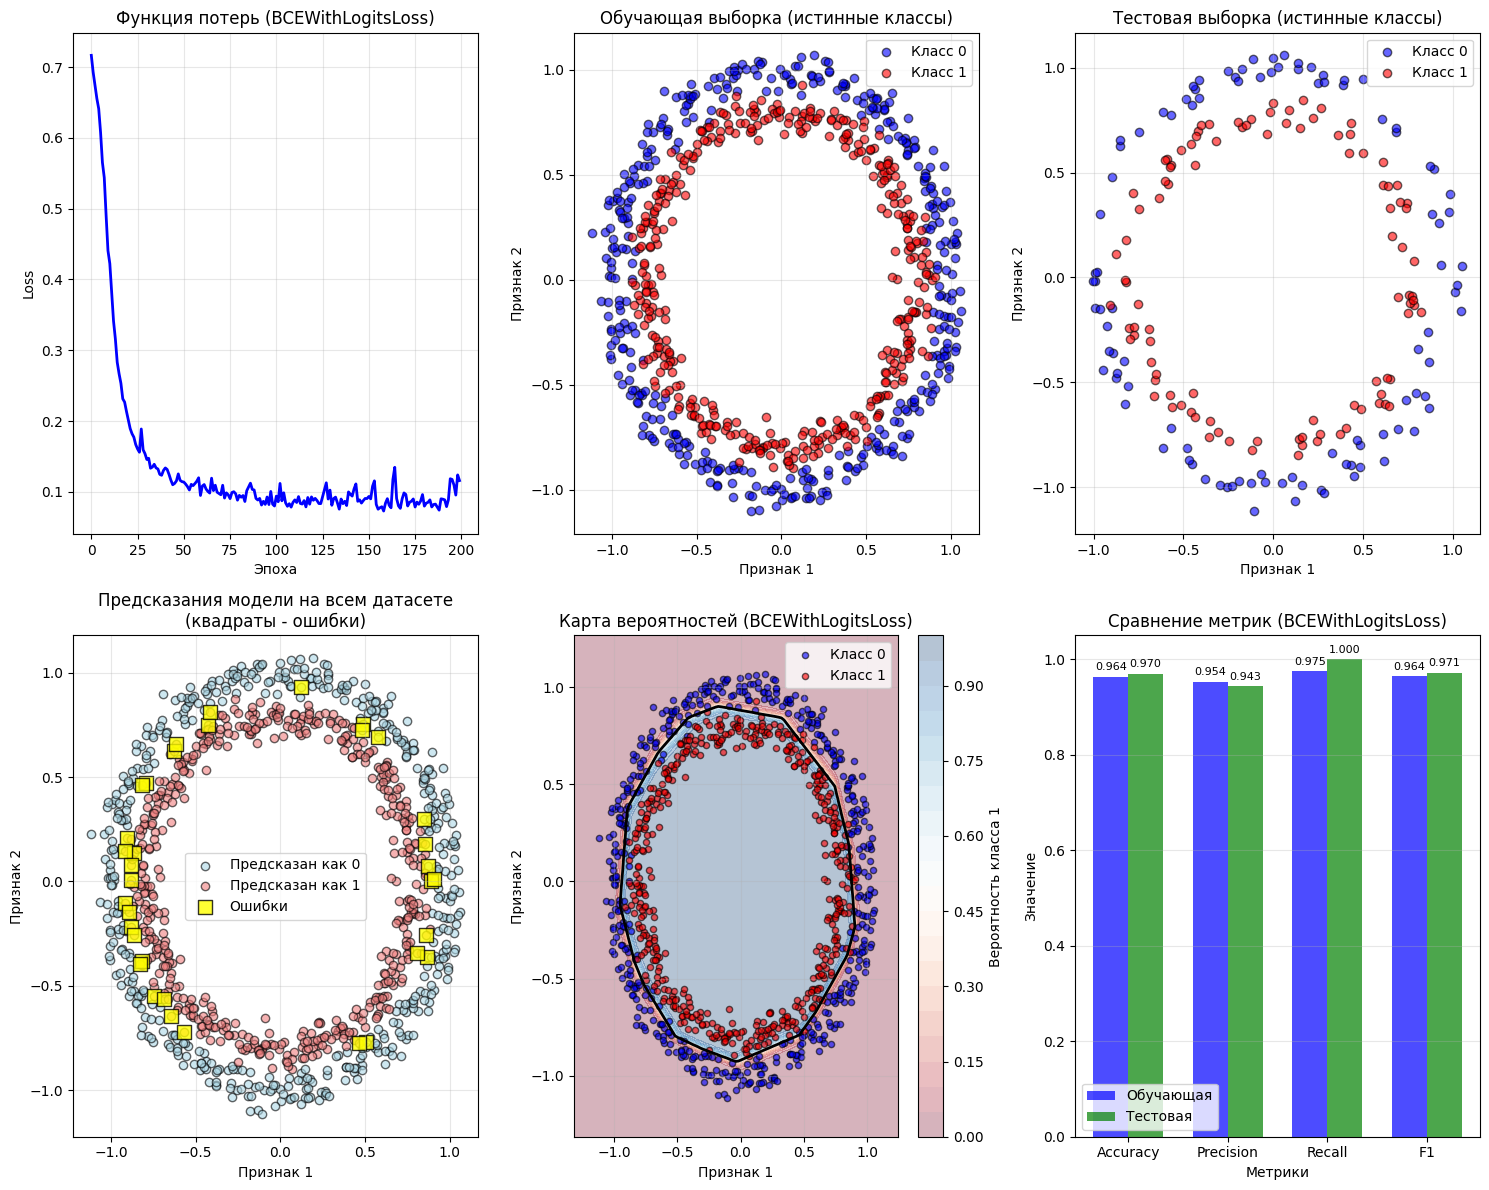

In [ ]:
# 8. Визуализация
plt.figure(figsize=(15, 12))

# График 1: Функция потерь
plt.subplot(2, 3, 1)
plt.plot(loss_history, color='blue', linewidth=2)
plt.title('Функция потерь (BCEWithLogitsLoss)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

# График 2: Исходные данные (обучающая выборка)
plt.subplot(2, 3, 2)
plt.scatter(X_train[y_train.flatten() == 0, 0].numpy(), X_train[y_train.flatten() == 0, 1].numpy(),
            c='blue', label='Класс 0', alpha=0.6, edgecolors='black')
plt.scatter(X_train[y_train.flatten() == 1, 0].numpy(), X_train[y_train.flatten() == 1, 1].numpy(),
            c='red', label='Класс 1', alpha=0.6, edgecolors='black')
plt.title('Обучающая выборка (истинные классы)')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.grid(True, alpha=0.3)

# График 3: Исходные данные (тестовая выборка)
plt.subplot(2, 3, 3)
plt.scatter(X_test[y_test.flatten() == 0, 0].numpy(), X_test[y_test.flatten() == 0, 1].numpy(),
            c='blue', label='Класс 0', alpha=0.6, edgecolors='black')
plt.scatter(X_test[y_test.flatten() == 1, 0].numpy(), X_test[y_test.flatten() == 1, 1].numpy(),
            c='red', label='Класс 1', alpha=0.6, edgecolors='black')
plt.title('Тестовая выборка (истинные классы)')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.grid(True, alpha=0.3)

# График 4: Предсказания модели на всем датасете
plt.subplot(2, 3, 4)

# Объединяем все данные
X_all = th.cat([X_train, X_test])
y_all_true = th.cat([y_train, y_test])

with th.no_grad():
    y_all_pred_logits = model(X_all)
    y_all_pred_proba = th.sigmoid(y_all_pred_logits)
    y_all_pred = (y_all_pred_proba >= 0.5).float()

# Преобразуем в numpy для визуализации
X_all_np = X_all.numpy()
y_all_true_np = y_all_true.numpy().flatten()
y_all_pred_np = y_all_pred.numpy().flatten()

# Рисуем предсказания
plt.scatter(X_all_np[y_all_pred_np == 0, 0], X_all_np[y_all_pred_np == 0, 1],
            c='lightblue', label='Предсказан как 0', alpha=0.6, edgecolors='black', marker='o')
plt.scatter(X_all_np[y_all_pred_np == 1, 0], X_all_np[y_all_pred_np == 1, 1],
            c='lightcoral', label='Предсказан как 1', alpha=0.6, edgecolors='black', marker='o')

# Обводим точки с ошибками
misclassified = (y_all_pred_np != y_all_true_np)
if np.any(misclassified):
    plt.scatter(X_all_np[misclassified, 0], X_all_np[misclassified, 1],
                c='yellow', label='Ошибки', alpha=0.8, edgecolors='black', s=100, marker='s')

plt.title('Предсказания модели на всем датасете\n(квадраты - ошибки)')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.grid(True, alpha=0.3)

# График 5: Граница решения и карта вероятностей
plt.subplot(2, 3, 5)

# Создаем сетку для визуализации границы
x_min, x_max = X_all_np[:, 0].min() - 0.2, X_all_np[:, 0].max() + 0.2
y_min, y_max = X_all_np[:, 1].min() - 0.2, X_all_np[:, 1].max() + 0.2
xx = np.arange(x_min, x_max, 0.02)
yy = np.arange(y_min, y_max, 0.02)
xx, yy = np.meshgrid(xx, yy)

# Предсказания для сетки (вероятности)
grid_tensor = th.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
with th.no_grad():
    grid_pred_logits = model(grid_tensor)
    grid_pred_proba = th.sigmoid(grid_pred_logits).numpy()
grid_pred_proba = grid_pred_proba.reshape(xx.shape)

# Рисуем карту вероятностей
plt.contourf(xx, yy, grid_pred_proba, alpha=0.3, cmap=plt.cm.RdBu, levels=20)
plt.colorbar(label='Вероятность класса 1')

plt.scatter(X_all_np[y_all_true_np == 0, 0], X_all_np[y_all_true_np == 0, 1],
            c='blue', label='Класс 0', alpha=0.6, edgecolors='black', s=20)
plt.scatter(X_all_np[y_all_true_np == 1, 0], X_all_np[y_all_true_np == 1, 1],
            c='red', label='Класс 1', alpha=0.6, edgecolors='black', s=20)

# Добавляем контур границы решения (p=0.5)
plt.contour(xx, yy, grid_pred_proba, levels=[0.5], colors='black', linewidths=2)

plt.title('Карта вероятностей (BCEWithLogitsLoss)')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.grid(True, alpha=0.3)

# График 6: Сравнение метрик
plt.subplot(2, 3, 6)

# Получаем метрики для обоих выборок
def get_metrics_dict_bce(model, X, y):
    with th.no_grad():
        y_pred_logits = model(X)
        y_pred_proba = th.sigmoid(y_pred_logits)
        y_pred = (y_pred_proba >= 0.5).float().numpy()
    y_true = y.numpy()

    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0)
    }

train_metrics = get_metrics_dict_bce(model, X_train, y_train)
test_metrics = get_metrics_dict_bce(model, X_test, y_test)

# Рисуем столбцы
x = np.arange(len(train_metrics))
width = 0.35

plt.bar(x - width/2, list(train_metrics.values()), width, label='Обучающая', color='blue', alpha=0.7)
plt.bar(x + width/2, list(test_metrics.values()), width, label='Тестовая', color='green', alpha=0.7)

plt.xlabel('Метрики')
plt.ylabel('Значение')
plt.title('Сравнение метрик (BCEWithLogitsLoss)')
plt.xticks(x, list(train_metrics.keys()))
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for i, (key, value) in enumerate(train_metrics.items()):
    plt.text(i - width/2, value + 0.01, f'{value:.3f}', ha='center', va='bottom', fontsize=8)
for i, (key, value) in enumerate(test_metrics.items()):
    plt.text(i + width/2, value + 0.01, f'{value:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# 9. Сравнение с CrossEntropyLoss из задачи 2
print("5. Сравнение с CrossEntropyLoss (задача 2):")
print(f"{'Метрика':<15} {'CrossEntropy':<15} {'BCEWithLogits':<15} {'Разница':<15}")

# Данные из задачи 2
ce_metrics = {
    'Accuracy': 0.9700,
    'Precision': 0.9700,
    'Recall': 0.9700,
    'F1': 0.9700
}

for metric in train_metrics.keys():
    ce_val = ce_metrics[metric]
    bce_val = test_metrics[metric]
    difference = bce_val - ce_val
    print(f"{metric:<15} {ce_val:<15.4f} {bce_val:<15.4f} {difference:+.4f}")

5. Сравнение с CrossEntropyLoss (задача 2):
Метрика         CrossEntropy    BCEWithLogits   Разница        
Accuracy        0.9700          0.9700          +0.0000
Precision       0.9700          0.9434          -0.0266
Recall          0.9700          1.0000          +0.0300
F1              0.9700          0.9709          +0.0009


In [ ]:
# 10. Демонстрация различий между loss-функциями
print("6. Различия между CrossEntropyLoss и BCEWithLogitsLoss:")

print("""
CrossEntropyLoss:
  • Для многоклассовой классификации (2+ класса)
  • Выходной слой: количество нейронов = число классов
  • Внутренне применяет softmax
  • Метки: LongTensor (0, 1, 2, ...)

BCEWithLogitsLoss:
  • Только для бинарной классификации
  • Выходной слой: 1 нейрон
  • Внутренне применяет sigmoid
  • Метки: FloatTensor (0.0, 1.0)
  • Более стабилен численно, чем BCELoss
""")


6. Различия между CrossEntropyLoss и BCEWithLogitsLoss:

CrossEntropyLoss:
  • Для многоклассовой классификации (2+ класса)
  • Выходной слой: количество нейронов = число классов
  • Внутренне применяет softmax
  • Метки: LongTensor (0, 1, 2, ...)

BCEWithLogitsLoss:
  • Только для бинарной классификации
  • Выходной слой: 1 нейрон
  • Внутренне применяет sigmoid
  • Метки: FloatTensor (0.0, 1.0)
  • Более стабилен численно, чем BCELoss



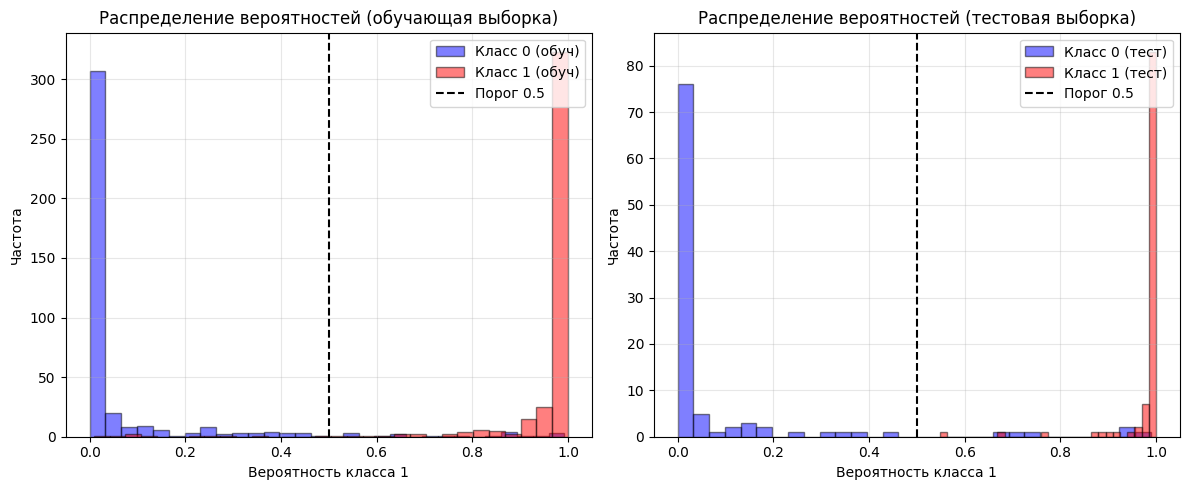

In [ ]:
# 11. Дополнительный анализ: распределение предсказанных вероятностей
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
with th.no_grad():
    train_proba = th.sigmoid(model(X_train)).numpy()
    test_proba = th.sigmoid(model(X_test)).numpy()

plt.hist(train_proba[y_train.numpy().flatten() == 0], bins=30, alpha=0.5,
         label='Класс 0 (обуч)', color='blue', edgecolor='black')
plt.hist(train_proba[y_train.numpy().flatten() == 1], bins=30, alpha=0.5,
         label='Класс 1 (обуч)', color='red', edgecolor='black')
plt.axvline(x=0.5, color='black', linestyle='--', label='Порог 0.5')
plt.title('Распределение вероятностей (обучающая выборка)')
plt.xlabel('Вероятность класса 1')
plt.ylabel('Частота')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(test_proba[y_test.numpy().flatten() == 0], bins=30, alpha=0.5,
         label='Класс 0 (тест)', color='blue', edgecolor='black')
plt.hist(test_proba[y_test.numpy().flatten() == 1], bins=30, alpha=0.5,
         label='Класс 1 (тест)', color='red', edgecolor='black')
plt.axvline(x=0.5, color='black', linestyle='--', label='Порог 0.5')
plt.title('Распределение вероятностей (тестовая выборка)')
plt.xlabel('Вероятность класса 1')
plt.ylabel('Частота')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<p class="task" id="4"></p>

4\. На практике часто задача классификации является несбалансированной. В файлах каталога `imb_task` содержится несбалансированный набор данных. Обучите модель без учета несбалансированности классов (аналогично предыдущим заданиям, можно использовать любую подходящую функцию потерь). Повысьте качество модели (в смысле F1) путем модификации функции потерь (указания специального аргумента, позволяющего учесть несбалансированность классов).

- [ ] Проверено на семинаре

In [ ]:
# 1. Загрузка несбалансированного датасета из файлов .th
print("1. Загрузка несбалансированного датасета")

# Путь к файлам
X_path = os.path.join('imb_X.th')
y_path = os.path.join('imb_y.th')

# Загружаем тензоры
X = th.load(X_path)
y = th.load(y_path)

# Преобразуем в нужный формат, если необходимо
if y.dim() == 1:
    y = y.long()
else:
    y = y.squeeze().long()

print(f"Загружены данные: X={X.shape}, y={y.shape}")
print(f"Тип X: {X.dtype}, Тип y: {y.dtype}")

# Анализ дисбаланса
class_counts = np.bincount(y.numpy())
print(f"\nРаспределение классов:")
print(f"  Класс 0: {class_counts[0]} samples ({class_counts[0]/len(y)*100:.2f}%)")
print(f"  Класс 1: {class_counts[1]} samples ({class_counts[1]/len(y)*100:.2f}%)")
if len(class_counts) > 2:
    for i in range(2, len(class_counts)):
        print(f"  Класс {i}: {class_counts[i]} samples ({class_counts[i]/len(y)*100:.2f}%)")
print(f"  Коэффициент дисбаланса (0/1): {class_counts[0]/class_counts[1]:.2f}:1")

# 2. Разделение на обучающую и тестовую выборки (80/20) со стратификацией
X_np = X.numpy()
y_np = y.numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X_np, y_np, test_size=0.2, random_state=42, stratify=y_np
)

X_train = th.FloatTensor(X_train)
y_train = th.LongTensor(y_train)
X_test = th.FloatTensor(X_test)
y_test = th.LongTensor(y_test)

print(f"\nОбучающая выборка: X={X_train.shape}, y={y_train.shape}")
print(f"  Распределение: {np.bincount(y_train.numpy())}")
print(f"Тестовая выборка: X={X_test.shape}, y={y_test.shape}")
print(f"  Распределение: {np.bincount(y_test.numpy())}")

# 3. Определение модели
print("\n2. Создание модели")

class ImbalancedModel(nn.Module):
    def __init__(self, n_features: int, n_hidden: int, n_classes: int):
        super().__init__()
        self.layer1 = nn.Linear(n_features, n_hidden)
        self.activation = nn.ReLU()
        self.layer2 = nn.Linear(n_hidden, n_hidden)
        self.activation2 = nn.ReLU()
        self.layer3 = nn.Linear(n_hidden, n_classes)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.layer1(x)
        x = self.activation(x)
        x = self.layer2(x)
        x = self.activation2(x)
        x = self.layer3(x)
        return x

# 4. Функция для обучения модели
def train_model(model, criterion, optimizer, train_loader, n_epochs=100, model_name=""):
    loss_history = []

    for epoch in range(n_epochs):
        epoch_loss = 0.0
        num_batches = 0

        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            y_pred = model(batch_X)
            loss = criterion(y_pred, batch_y)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            num_batches += 1

        avg_loss = epoch_loss / num_batches
        loss_history.append(avg_loss)

        if (epoch + 1) % 20 == 0:
            print(f"  {model_name} - Эпоха {epoch + 1}/{n_epochs}, Loss: {avg_loss:.6f}")

    return loss_history

# 5. Функция для оценки модели
def evaluate_model(model, X, y, dataset_name=""):
    model.eval()
    with th.no_grad():
        y_pred_logits = model(X)
        y_pred = th.argmax(y_pred_logits, dim=1).numpy()

    y_true = y.numpy()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    # Для бинарной классификации также считаем отдельно для каждого класса
    if len(np.unique(y_true)) == 2:
        precision_bin = precision_score(y_true, y_pred, average='binary', zero_division=0)
        recall_bin = recall_score(y_true, y_pred, average='binary', zero_division=0)
        f1_bin = f1_score(y_true, y_pred, average='binary', zero_division=0)
    else:
        precision_bin = precision
        recall_bin = recall
        f1_bin = f1

    cm = confusion_matrix(y_true, y_pred)

    print(f"\n{dataset_name} Метрики:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision (weighted): {precision:.4f}")
    print(f"  Recall (weighted):    {recall:.4f}")
    print(f"  F1-score (weighted):  {f1:.4f}")
    if len(np.unique(y_true)) == 2:
        print(f"  Precision (binary): {precision_bin:.4f}")
        print(f"  Recall (binary):    {recall_bin:.4f}")
        print(f"  F1-score (binary):  {f1_bin:.4f}")
    print(f"  Confusion Matrix:")
    for row in cm:
        print(f"    {row}")

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'precision_bin': precision_bin if len(np.unique(y_true)) == 2 else precision,
        'recall_bin': recall_bin if len(np.unique(y_true)) == 2 else recall,
        'f1_bin': f1_bin if len(np.unique(y_true)) == 2 else f1,
        'confusion_matrix': cm
    }

# Определяем количество классов
n_classes = len(np.unique(y.numpy()))
print(f"\nКоличество классов: {n_classes}")

1. Загрузка несбалансированного датасета
Загружены данные: X=torch.Size([1650, 2]), y=torch.Size([1650])
Тип X: torch.float64, Тип y: torch.int64

Распределение классов:
  Класс 0: 1500 samples (90.91%)
  Класс 1: 150 samples (9.09%)
  Коэффициент дисбаланса (0/1): 10.00:1

Обучающая выборка: X=torch.Size([1320, 2]), y=torch.Size([1320])
  Распределение: [1200  120]
Тестовая выборка: X=torch.Size([330, 2]), y=torch.Size([330])
  Распределение: [300  30]

2. Создание модели

Количество классов: 2


In [ ]:
# 6. МОДЕЛЬ 1: Без учета дисбаланса
model_no_weight = ImbalancedModel(n_features=X.shape[1], n_hidden=32, n_classes=n_classes)
criterion_no_weight = nn.CrossEntropyLoss()  # Стандартная loss без весов
optimizer_no_weight = optim.Adam(model_no_weight.parameters(), lr=0.001)

# Подготовка DataLoader
train_dataset = th.utils.data.TensorDataset(X_train, y_train)
train_loader = th.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)

# Обучение
print("Обучение модели без учета дисбаланса")
loss_no_weight = train_model(model_no_weight, criterion_no_weight, optimizer_no_weight,
                             train_loader, n_epochs=100, model_name="Без весов")

# Оценка
print("\nОценка модели без учета дисбаланса:")
metrics_no_weight_train = evaluate_model(model_no_weight, X_train, y_train, "Обучающая (без весов)")
metrics_no_weight_test = evaluate_model(model_no_weight, X_test, y_test, "Тестовая (без весов)")

Обучение модели без учета дисбаланса
  Без весов - Эпоха 20/100, Loss: 0.208846
  Без весов - Эпоха 40/100, Loss: 0.207325
  Без весов - Эпоха 60/100, Loss: 0.194678
  Без весов - Эпоха 80/100, Loss: 0.196809
  Без весов - Эпоха 100/100, Loss: 0.189649

Оценка модели без учета дисбаланса:

Обучающая (без весов) Метрики:
  Accuracy:  0.9220
  Precision (weighted): 0.9081
  Recall (weighted):    0.9220
  F1-score (weighted):  0.9073
  Precision (binary): 0.6667
  Recall (binary):    0.2833
  F1-score (binary):  0.3977
  Confusion Matrix:
    [1183   17]
    [86 34]

Тестовая (без весов) Метрики:
  Accuracy:  0.9333
  Precision (weighted): 0.9277
  Recall (weighted):    0.9333
  F1-score (weighted):  0.9200
  Precision (binary): 0.8333
  Recall (binary):    0.3333
  F1-score (binary):  0.4762
  Confusion Matrix:
    [298   2]
    [20 10]


In [ ]:
# 7. МОДЕЛЬ 2: С учетом дисбаланса через веса классов в CrossEntropyLoss

# Вычисляем веса классов (обратно пропорционально частоте)
class_counts = np.bincount(y_train.numpy())
n_samples = len(y_train)

# Веса = n_samples / (n_classes * class_counts)
weights = n_samples / (n_classes * class_counts)
weights_tensor = th.FloatTensor(weights)

print(f"Веса классов:")
for i, w in enumerate(weights):
    print(f"  Класс {i}: {w:.4f} (частота: {class_counts[i]/n_samples:.4f})")

model_weighted = ImbalancedModel(n_features=X.shape[1], n_hidden=32, n_classes=n_classes)
criterion_weighted = nn.CrossEntropyLoss(weight=weights_tensor)  # Loss с весами
optimizer_weighted = optim.Adam(model_weighted.parameters(), lr=0.001)

# Обучение
print("\nОбучение модели с весами классов")
loss_weighted = train_model(model_weighted, criterion_weighted, optimizer_weighted,
                           train_loader, n_epochs=100, model_name="С весами")

# Оценка
print("\nОценка модели с весами классов:")
metrics_weighted_train = evaluate_model(model_weighted, X_train, y_train, "Обучающая (с весами)")
metrics_weighted_test = evaluate_model(model_weighted, X_test, y_test, "Тестовая (с весами)")

Веса классов:
  Класс 0: 0.5500 (частота: 0.9091)
  Класс 1: 5.5000 (частота: 0.0909)

Обучение модели с весами классов
  С весами - Эпоха 20/100, Loss: 0.416424
  С весами - Эпоха 40/100, Loss: 0.386362
  С весами - Эпоха 60/100, Loss: 0.385381
  С весами - Эпоха 80/100, Loss: 0.386771
  С весами - Эпоха 100/100, Loss: 0.372970

Оценка модели с весами классов:

Обучающая (с весами) Метрики:
  Accuracy:  0.8258
  Precision (weighted): 0.9204
  Recall (weighted):    0.8258
  F1-score (weighted):  0.8568
  Precision (binary): 0.3226
  Recall (binary):    0.8333
  F1-score (binary):  0.4651
  Confusion Matrix:
    [990 210]
    [ 20 100]

Тестовая (с весами) Метрики:
  Accuracy:  0.8242
  Precision (weighted): 0.9125
  Recall (weighted):    0.8242
  F1-score (weighted):  0.8545
  Precision (binary): 0.3108
  Recall (binary):    0.7667
  F1-score (binary):  0.4423
  Confusion Matrix:
    [249  51]
    [ 7 23]


In [ ]:
# 8. Сравнение результатов
print("Тестовые метрики (weighted average):")
print(f"{'Метрика':<15} {'Без весов':<15} {'С весами':<15} {'Изменение':<15}")

metrics_to_compare = ['accuracy', 'precision', 'recall', 'f1']
for metric in metrics_to_compare:
    without = metrics_no_weight_test[metric]
    with_weight = metrics_weighted_test[metric]
    change = with_weight - without
    print(f"{metric.capitalize():<15} {without:<15.4f} {with_weight:<15.4f} {change:+.4f}")

# Для бинарной классификации показываем также binary метрики
if n_classes == 2:
    print("Тестовые метрики (binary - для класса 1):")
    print(f"{'Метрика':<15} {'Без весов':<15} {'С весами':<15} {'Изменение':<15}")

    bin_metrics = ['precision_bin', 'recall_bin', 'f1_bin']
    for metric in bin_metrics:
        without = metrics_no_weight_test[metric]
        with_weight = metrics_weighted_test[metric]
        change = with_weight - without
        display_name = metric.replace('_bin', '').capitalize()
        print(f"{display_name:<15} {without:<15.4f} {with_weight:<15.4f} {change:+.4f}")

Тестовые метрики (weighted average):
Метрика         Без весов       С весами        Изменение      
Accuracy        0.9333          0.8242          -0.1091
Precision       0.9277          0.9125          -0.0152
Recall          0.9333          0.8242          -0.1091
F1              0.9200          0.8545          -0.0656
Тестовые метрики (binary - для класса 1):
Метрика         Без весов       С весами        Изменение      
Precision       0.8333          0.3108          -0.5225
Recall          0.3333          0.7667          +0.4333
F1              0.4762          0.4423          -0.0339


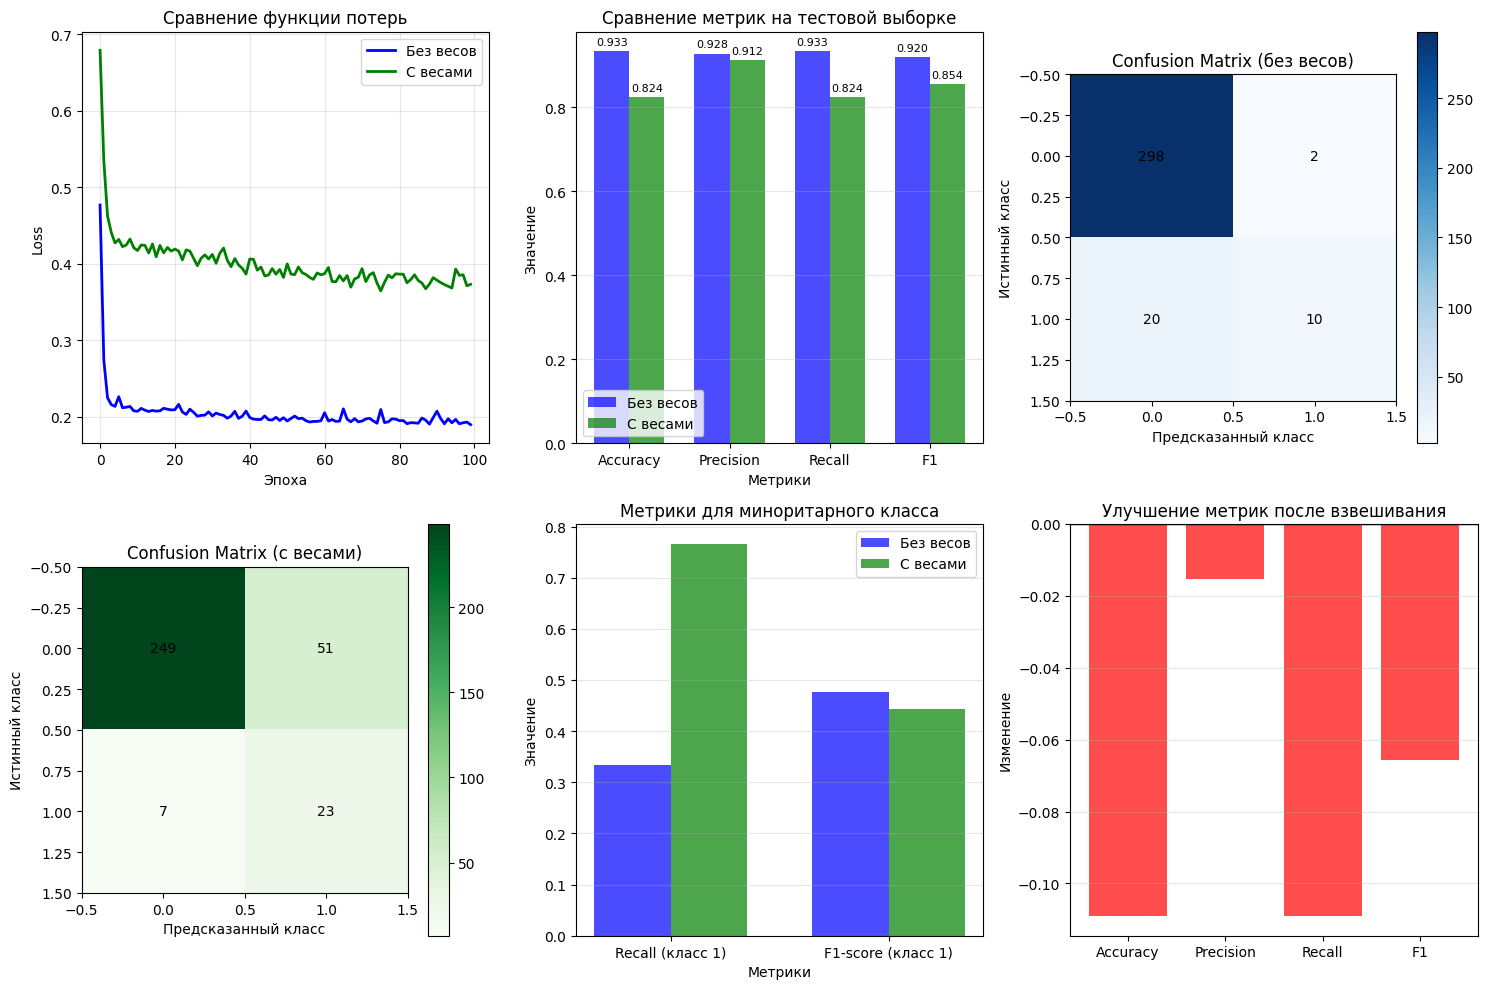

In [ ]:
# 9. Визуализация
plt.figure(figsize=(15, 10))

# График 1: Сравнение loss
plt.subplot(2, 3, 1)
plt.plot(loss_no_weight, label='Без весов', color='blue', linewidth=2)
plt.plot(loss_weighted, label='С весами', color='green', linewidth=2)
plt.title('Сравнение функции потерь')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# График 2: Сравнение метрик (столбцы)
plt.subplot(2, 3, 2)
x = np.arange(len(metrics_to_compare))
width = 0.35

without_values = [metrics_no_weight_test[m] for m in metrics_to_compare]
with_values = [metrics_weighted_test[m] for m in metrics_to_compare]

plt.bar(x - width/2, without_values, width, label='Без весов', color='blue', alpha=0.7)
plt.bar(x + width/2, with_values, width, label='С весами', color='green', alpha=0.7)

plt.xlabel('Метрики')
plt.ylabel('Значение')
plt.title('Сравнение метрик на тестовой выборке')
plt.xticks(x, [m.capitalize() for m in metrics_to_compare])
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for i, v in enumerate(without_values):
    plt.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=8)
for i, v in enumerate(with_values):
    plt.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

# График 3: Confusion Matrix для модели без весов
plt.subplot(2, 3, 3)
cm_no = metrics_no_weight_test['confusion_matrix']
plt.imshow(cm_no, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix (без весов)')
plt.colorbar()
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
for i in range(cm_no.shape[0]):
    for j in range(cm_no.shape[1]):
        plt.text(j, i, str(cm_no[i, j]), ha='center', va='center', color='black')

# График 4: Confusion Matrix для модели с весами
plt.subplot(2, 3, 4)
cm_weighted = metrics_weighted_test['confusion_matrix']
plt.imshow(cm_weighted, interpolation='nearest', cmap='Greens')
plt.title('Confusion Matrix (с весами)')
plt.colorbar()
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
for i in range(cm_weighted.shape[0]):
    for j in range(cm_weighted.shape[1]):
        plt.text(j, i, str(cm_weighted[i, j]), ha='center', va='center', color='black')

# График 5: Сравнение для миноритарного класса (если бинарная классификация)
plt.subplot(2, 3, 5)
if n_classes == 2:
    bin_metrics_display = ['Recall (класс 1)', 'F1-score (класс 1)']
    x = np.arange(len(bin_metrics_display))
    width = 0.35

    recall_values = [metrics_no_weight_test['recall_bin'], metrics_weighted_test['recall_bin']]
    f1_values = [metrics_no_weight_test['f1_bin'], metrics_weighted_test['f1_bin']]

    plt.bar(x - width/2, [recall_values[0], f1_values[0]], width, label='Без весов', color='blue', alpha=0.7)
    plt.bar(x + width/2, [recall_values[1], f1_values[1]], width, label='С весами', color='green', alpha=0.7)

    plt.xlabel('Метрики')
    plt.ylabel('Значение')
    plt.title('Метрики для миноритарного класса')
    plt.xticks(x, bin_metrics_display)
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
else:
    plt.text(0.5, 0.5, 'Многоклассовая классификация\n(метрики для каждого класса\nсмотрите в выводе)',
             ha='center', va='center', fontsize=12, transform=plt.gca().transAxes)
    plt.title('Информация')
    plt.axis('off')

# График 6: Улучшение метрик
plt.subplot(2, 3, 6)
improvements = [with_values[i] - without_values[i] for i in range(len(without_values))]
colors = ['green' if imp > 0 else 'red' for imp in improvements]
plt.bar([m.capitalize() for m in metrics_to_compare], improvements, color=colors, alpha=0.7)
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.title('Улучшение метрик после взвешивания')
plt.ylabel('Изменение')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# 10. Детальный анализ для каждого класса

# Получаем confusion matrices
cm_no = metrics_no_weight_test['confusion_matrix']
cm_weighted = metrics_weighted_test['confusion_matrix']

print("Качество по каждому классу (Recall):")
print(f"{'Класс':<10} {'Без весов':<15} {'С весами':<15} {'Изменение':<15}")

for i in range(n_classes):
    # Recall для класса i = TP_i / (TP_i + FN_i)
    tp_no = cm_no[i, i]
    fn_no = np.sum(cm_no[i, :]) - tp_no
    recall_no = tp_no / (tp_no + fn_no) if (tp_no + fn_no) > 0 else 0

    tp_weighted = cm_weighted[i, i]
    fn_weighted = np.sum(cm_weighted[i, :]) - tp_weighted
    recall_weighted = tp_weighted / (tp_weighted + fn_weighted) if (tp_weighted + fn_weighted) > 0 else 0

    change = recall_weighted - recall_no
    print(f"{i:<10} {recall_no:<15.4f} {recall_weighted:<15.4f} {change:+.4f}")

Качество по каждому классу (Recall):
Класс      Без весов       С весами        Изменение      
0          0.9933          0.8300          -0.1633
1          0.3333          0.7667          +0.4333


In [ ]:
# 11. Выводы
print("""
Влияние учета дисбаланса через веса классов:

1. Плюсы:
   + Увеличивает Recall на миноритарных классах
   + Улучшает сбалансированные метрики (weighted F1)
   + Модель лучше обнаруживает редкие классы

2. Минусы:
   - Может снизить точность на мажоритарных классах
   - Возможно небольшое снижение общей Accuracy
   - Требует подбора весов

3. Когда использовать:
   * Медицинская диагностика (важно найти болезнь)
   * Обнаружение мошенничества
   * Предсказание редких событий
   * Любые задачи с сильным дисбалансом
""")

# Сохраняем модели для задачи 5
th.save(model_no_weight.state_dict(), os.path.join('model_no_weight.pth'))
th.save(model_weighted.state_dict(), os.path.join('model_weighted.pth'))


Влияние учета дисбаланса через веса классов:

1. Плюсы:
   + Увеличивает Recall на миноритарных классах
   + Улучшает сбалансированные метрики (weighted F1)
   + Модель лучше обнаруживает редкие классы

2. Минусы:
   - Может снизить точность на мажоритарных классах
   - Возможно небольшое снижение общей Accuracy
   - Требует подбора весов

3. Когда использовать:
   * Медицинская диагностика (важно найти болезнь)
   * Обнаружение мошенничества
   * Предсказание редких событий
   * Любые задачи с сильным дисбалансом



<p class="task" id="5"></p>

5\. Повторите решение задачи 4, повысив качество модели за счет использования `WeightedRandomSampler` вместо модификации функции потерь.

- [ ] Проверено на семинаре

In [ ]:
# 1. Загрузка несбалансированного датасета
print("1. Загрузка несбалансированного датасета")

# Путь к файлам (в текущей папке)
X_path = 'imb_X.th'
y_path = 'imb_y.th'

# Загружаем тензоры
X = th.load(X_path)
y = th.load(y_path)

# Преобразуем в нужный формат
if y.dim() == 1:
    y = y.long()
else:
    y = y.squeeze().long()

print(f"Загружены данные: X={X.shape}, y={y.shape}")
print(f"Тип X: {X.dtype}, Тип y: {y.dtype}")

# Анализ дисбаланса
class_counts = np.bincount(y.numpy())
print(f"\nРаспределение классов:")
print(f"  Класс 0: {class_counts[0]} samples ({class_counts[0]/len(y)*100:.2f}%)")
print(f"  Класс 1: {class_counts[1]} samples ({class_counts[1]/len(y)*100:.2f}%)")
print(f"  Коэффициент дисбаланса (0/1): {class_counts[0]/class_counts[1]:.2f}:1")

# 2. Разделение на обучающую и тестовую выборки (80/20) со стратификацией
X_np = X.numpy()
y_np = y.numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X_np, y_np, test_size=0.2, random_state=42, stratify=y_np
)

X_train = th.FloatTensor(X_train)
y_train = th.LongTensor(y_train)
X_test = th.FloatTensor(X_test)
y_test = th.LongTensor(y_test)

print(f"\nОбучающая выборка: X={X_train.shape}, y={y_train.shape}")
print(f"  Распределение: {np.bincount(y_train.numpy())}")
print(f"Тестовая выборка: X={X_test.shape}, y={y_test.shape}")
print(f"  Распределение: {np.bincount(y_test.numpy())}")

# 3. Определение модели (та же архитектура, что в задаче 4)
print("\n2. Создание модели")

class ImbalancedModel(nn.Module):
    def __init__(self, n_features: int, n_hidden: int, n_classes: int):
        super().__init__()
        self.layer1 = nn.Linear(n_features, n_hidden)
        self.activation = nn.ReLU()
        self.layer2 = nn.Linear(n_hidden, n_hidden)
        self.activation2 = nn.ReLU()
        self.layer3 = nn.Linear(n_hidden, n_classes)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.layer1(x)
        x = self.activation(x)
        x = self.layer2(x)
        x = self.activation2(x)
        x = self.layer3(x)
        return x

# 4. Функция для обучения модели
def train_model(model, criterion, optimizer, train_loader, n_epochs=100, model_name=""):
    loss_history = []

    for epoch in range(n_epochs):
        epoch_loss = 0.0
        num_batches = 0

        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            y_pred = model(batch_X)
            loss = criterion(y_pred, batch_y)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            num_batches += 1

        avg_loss = epoch_loss / num_batches
        loss_history.append(avg_loss)

        if (epoch + 1) % 20 == 0:
            print(f"  {model_name} - Эпоха {epoch + 1}/{n_epochs}, Loss: {avg_loss:.6f}")

    return loss_history

# 5. Функция для оценки модели
def evaluate_model(model, X, y, dataset_name=""):
    model.eval()
    with th.no_grad():
        y_pred_logits = model(X)
        y_pred = th.argmax(y_pred_logits, dim=1).numpy()

    y_true = y.numpy()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    # Для бинарной классификации также считаем отдельно для каждого класса
    precision_bin = precision_score(y_true, y_pred, average='binary', zero_division=0)
    recall_bin = recall_score(y_true, y_pred, average='binary', zero_division=0)
    f1_bin = f1_score(y_true, y_pred, average='binary', zero_division=0)

    cm = confusion_matrix(y_true, y_pred)

    print(f"\n{dataset_name} Метрики:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision (weighted): {precision:.4f}")
    print(f"  Recall (weighted):    {recall:.4f}")
    print(f"  F1-score (weighted):  {f1:.4f}")
    print(f"  Precision (binary): {precision_bin:.4f}")
    print(f"  Recall (binary):    {recall_bin:.4f}")
    print(f"  F1-score (binary):  {f1_bin:.4f}")
    print(f"  Confusion Matrix:")
    for row in cm:
        print(f"    {row}")

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'precision_bin': precision_bin,
        'recall_bin': recall_bin,
        'f1_bin': f1_bin,
        'confusion_matrix': cm
    }

# Определяем количество классов
n_classes = len(np.unique(y.numpy()))
print(f"\nКоличество классов: {n_classes}")

1. Загрузка несбалансированного датасета
Загружены данные: X=torch.Size([1650, 2]), y=torch.Size([1650])
Тип X: torch.float64, Тип y: torch.int64

Распределение классов:
  Класс 0: 1500 samples (90.91%)
  Класс 1: 150 samples (9.09%)
  Коэффициент дисбаланса (0/1): 10.00:1

Обучающая выборка: X=torch.Size([1320, 2]), y=torch.Size([1320])
  Распределение: [1200  120]
Тестовая выборка: X=torch.Size([330, 2]), y=torch.Size([330])
  Распределение: [300  30]

2. Создание модели

Количество классов: 2


In [ ]:
# 6. МОДЕЛЬ 1: Без учета дисбаланса (как в задаче 4)

model_no_weight = ImbalancedModel(n_features=X.shape[1], n_hidden=32, n_classes=n_classes)
criterion_no_weight = nn.CrossEntropyLoss()
optimizer_no_weight = optim.Adam(model_no_weight.parameters(), lr=0.001)

# Обычный DataLoader (без сэмплирования)
train_dataset = th.utils.data.TensorDataset(X_train, y_train)
train_loader_standard = th.utils.data.DataLoader(
    train_dataset, batch_size=32, shuffle=True
)

print("\nОбучение модели без учета дисбаланса")
loss_no_weight = train_model(model_no_weight, criterion_no_weight, optimizer_no_weight,
                             train_loader_standard, n_epochs=100, model_name="Без учета")

print("\nОценка модели без учета дисбаланса:")
metrics_no_weight_test = evaluate_model(model_no_weight, X_test, y_test, "Тестовая (без учета)")


Обучение модели без учета дисбаланса
  Без учета - Эпоха 20/100, Loss: 0.209013
  Без учета - Эпоха 40/100, Loss: 0.200683
  Без учета - Эпоха 60/100, Loss: 0.193307
  Без учета - Эпоха 80/100, Loss: 0.197127
  Без учета - Эпоха 100/100, Loss: 0.191224

Оценка модели без учета дисбаланса:

Тестовая (без учета) Метрики:
  Accuracy:  0.9394
  Precision (weighted): 0.9352
  Recall (weighted):    0.9394
  F1-score (weighted):  0.9292
  Precision (binary): 0.8571
  Recall (binary):    0.4000
  F1-score (binary):  0.5455
  Confusion Matrix:
    [298   2]
    [18 12]


In [ ]:
# 7. МОДЕЛЬ 2: С WeightedRandomSampler

# Вычисляем веса для каждого sample (обратно пропорционально частоте класса)
class_counts = np.bincount(y_train.numpy())
n_samples = len(y_train)

# Веса для каждого класса
class_weights = 1.0 / class_counts
# Нормализуем, чтобы сумма весов была равна количеству классов
class_weights = class_weights / class_weights.sum() * n_classes

print(f"Веса классов для сэмплирования:")
for i, w in enumerate(class_weights):
    print(f"  Класс {i}: {w:.4f} (частота: {class_counts[i]/n_samples:.4f})")

# Создаем веса для каждого sample
sample_weights = np.array([class_weights[label] for label in y_train.numpy()])
sample_weights = th.DoubleTensor(sample_weights)

# Создаем WeightedRandomSampler
sampler = th.utils.data.WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True  # Сэмплирование с возвращением
)

# Создаем DataLoader с сэмплером
train_dataset = th.utils.data.TensorDataset(X_train, y_train)
train_loader_sampler = th.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler
)

model_sampler = ImbalancedModel(n_features=X.shape[1], n_hidden=32, n_classes=n_classes)
criterion_sampler = nn.CrossEntropyLoss()  # Стандартная loss (без весов)
optimizer_sampler = optim.Adam(model_sampler.parameters(), lr=0.001)

print("\nОбучение модели с WeightedRandomSampler")
loss_sampler = train_model(model_sampler, criterion_sampler, optimizer_sampler,
                           train_loader_sampler, n_epochs=100, model_name="С сэмплером")

print("\nОценка модели с WeightedRandomSampler:")
metrics_sampler_test = evaluate_model(model_sampler, X_test, y_test, "Тестовая (с сэмплером)")

Веса классов для сэмплирования:
  Класс 0: 0.1818 (частота: 0.9091)
  Класс 1: 1.8182 (частота: 0.0909)

Обучение модели с WeightedRandomSampler
  С сэмплером - Эпоха 20/100, Loss: 0.388864
  С сэмплером - Эпоха 40/100, Loss: 0.360496
  С сэмплером - Эпоха 60/100, Loss: 0.373515
  С сэмплером - Эпоха 80/100, Loss: 0.353877
  С сэмплером - Эпоха 100/100, Loss: 0.362398

Оценка модели с WeightedRandomSampler:

Тестовая (с сэмплером) Метрики:
  Accuracy:  0.8152
  Precision (weighted): 0.9150
  Recall (weighted):    0.8152
  F1-score (weighted):  0.8485
  Precision (binary): 0.3038
  Recall (binary):    0.8000
  F1-score (binary):  0.4404
  Confusion Matrix:
    [245  55]
    [ 6 24]


In [ ]:
# 8. МОДЕЛЬ 3: С весами в loss (из задачи 4 для сравнения)

# Вычисляем веса для loss
loss_weights = n_samples / (n_classes * class_counts)
loss_weights_tensor = th.FloatTensor(loss_weights)

print(f"Веса классов для loss:")
for i, w in enumerate(loss_weights):
    print(f"  Класс {i}: {w:.4f}")

model_weighted = ImbalancedModel(n_features=X.shape[1], n_hidden=32, n_classes=n_classes)
criterion_weighted = nn.CrossEntropyLoss(weight=loss_weights_tensor)
optimizer_weighted = optim.Adam(model_weighted.parameters(), lr=0.001)

# Обычный DataLoader
train_loader_standard2 = th.utils.data.DataLoader(
    train_dataset, batch_size=32, shuffle=True
)

print("\nОбучение модели с весами в loss")
loss_weighted = train_model(model_weighted, criterion_weighted, optimizer_weighted,
                            train_loader_standard2, n_epochs=100, model_name="С весами в loss")

print("\nОценка модели с весами в loss:")
metrics_weighted_test = evaluate_model(model_weighted, X_test, y_test, "Тестовая (с весами в loss)")

Веса классов для loss:
  Класс 0: 0.5500
  Класс 1: 5.5000

Обучение модели с весами в loss
  С весами в loss - Эпоха 20/100, Loss: 0.406483
  С весами в loss - Эпоха 40/100, Loss: 0.386824
  С весами в loss - Эпоха 60/100, Loss: 0.391185
  С весами в loss - Эпоха 80/100, Loss: 0.377641
  С весами в loss - Эпоха 100/100, Loss: 0.370156

Оценка модели с весами в loss:

Тестовая (с весами в loss) Метрики:
  Accuracy:  0.8303
  Precision (weighted): 0.9135
  Recall (weighted):    0.8303
  F1-score (weighted):  0.8589
  Precision (binary): 0.3194
  Recall (binary):    0.7667
  F1-score (binary):  0.4510
  Confusion Matrix:
    [251  49]
    [ 7 23]


In [ ]:
# 9. Сравнение всех трех подходов
print("Тестовые метрики (binary - для миноритарного класса 1):")
print(f"{'Метрика':<15} {'Без учета':<15} {'Сэмплер':<15} {'Веса в loss':<15} {'Лучший':<15}")

bin_metrics = ['recall_bin', 'precision_bin', 'f1_bin']
metric_names = {'recall_bin': 'Recall', 'precision_bin': 'Precision', 'f1_bin': 'F1-score'}

for metric in bin_metrics:
    without = metrics_no_weight_test[metric]
    sampler = metrics_sampler_test[metric]
    weighted = metrics_weighted_test[metric]

    # Определяем лучший
    values = [without, sampler, weighted]
    best_idx = np.argmax(values)
    best_value = values[best_idx]
    best_label = ['Без учета', 'Сэмплер', 'Веса в loss'][best_idx]

    print(f"{metric_names[metric]:<15} {without:<15.4f} {sampler:<15.4f} {weighted:<15.4f} {best_label:<15}")

Тестовые метрики (binary - для миноритарного класса 1):
Метрика         Без учета       Сэмплер         Веса в loss     Лучший         
Recall          0.4000          0.8000          0.7667          Сэмплер        
Precision       0.8571          0.3038          0.3194          Без учета      
F1-score        0.5455          0.4404          0.4510          Без учета      


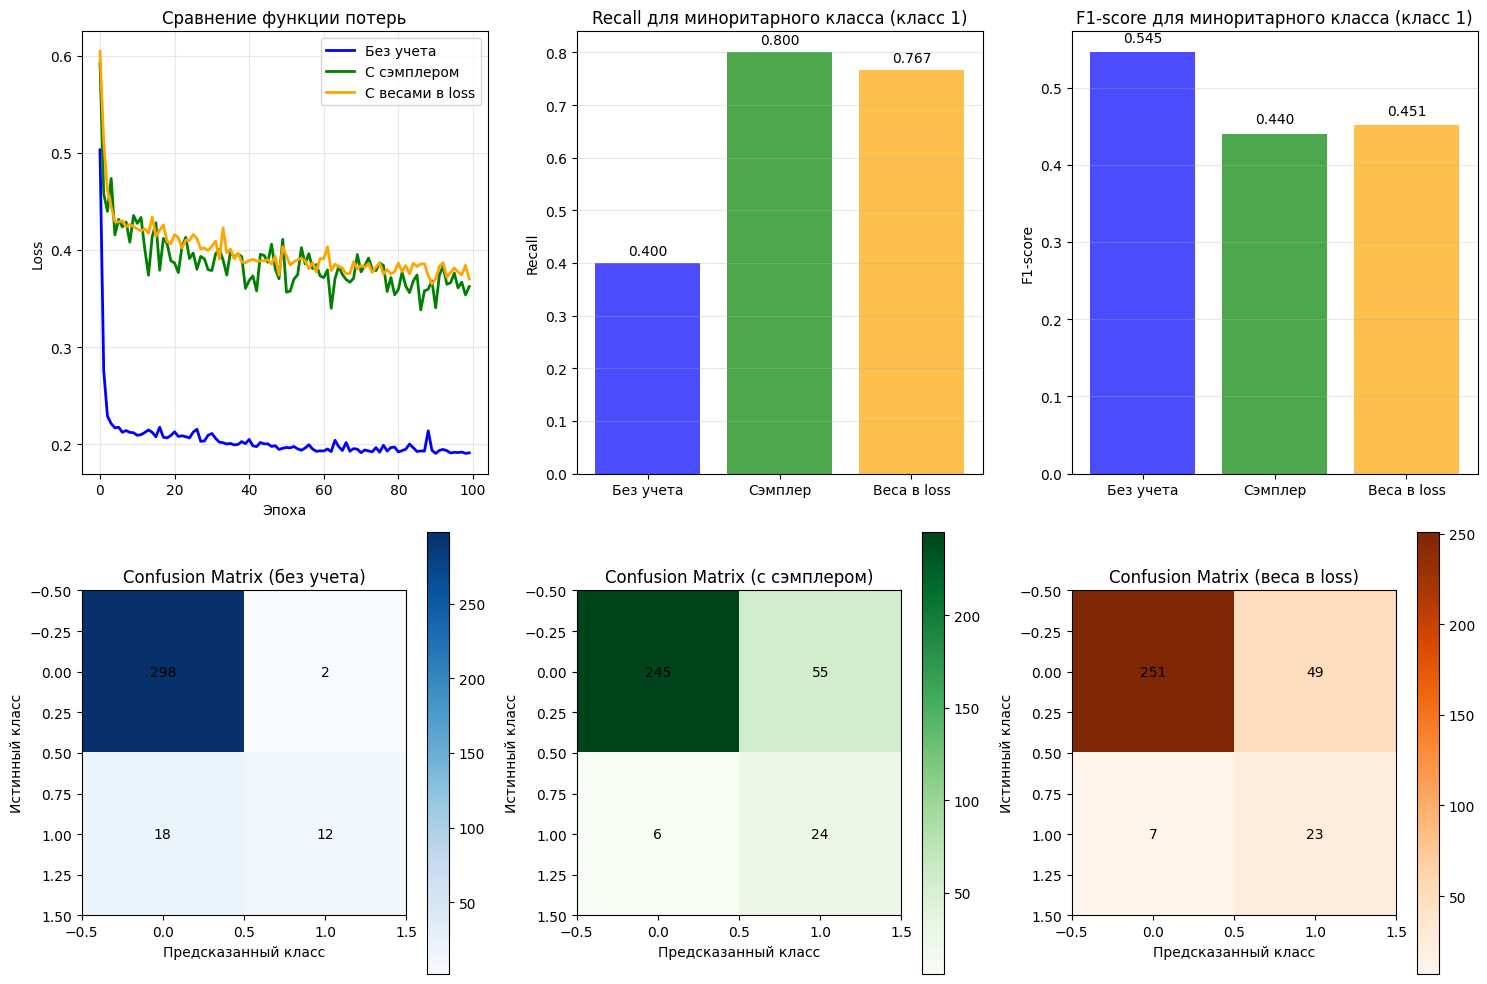

In [ ]:
# 10. Визуализация сравнения
plt.figure(figsize=(15, 10))

# График 1: Сравнение loss
plt.subplot(2, 3, 1)
plt.plot(loss_no_weight, label='Без учета', color='blue', linewidth=2)
plt.plot(loss_sampler, label='С сэмплером', color='green', linewidth=2)
plt.plot(loss_weighted, label='С весами в loss', color='orange', linewidth=2)
plt.title('Сравнение функции потерь')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# График 2: Сравнение Recall для класса 1
plt.subplot(2, 3, 2)
models = ['Без учета', 'Сэмплер', 'Веса в loss']
recalls = [
    metrics_no_weight_test['recall_bin'],
    metrics_sampler_test['recall_bin'],
    metrics_weighted_test['recall_bin']
]
colors = ['blue', 'green', 'orange']
bars = plt.bar(models, recalls, color=colors, alpha=0.7)
plt.title('Recall для миноритарного класса (класс 1)')
plt.ylabel('Recall')
plt.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, recalls):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom')

# График 3: Сравнение F1-score для класса 1
plt.subplot(2, 3, 3)
f1_scores = [
    metrics_no_weight_test['f1_bin'],
    metrics_sampler_test['f1_bin'],
    metrics_weighted_test['f1_bin']
]
bars = plt.bar(models, f1_scores, color=colors, alpha=0.7)
plt.title('F1-score для миноритарного класса (класс 1)')
plt.ylabel('F1-score')
plt.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom')

# График 4: Confusion Matrix для модели без учета
plt.subplot(2, 3, 4)
cm_no = metrics_no_weight_test['confusion_matrix']
plt.imshow(cm_no, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix (без учета)')
plt.colorbar()
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm_no[i, j]), ha='center', va='center', color='black')

# График 5: Confusion Matrix для модели с сэмплером
plt.subplot(2, 3, 5)
cm_sampler = metrics_sampler_test['confusion_matrix']
plt.imshow(cm_sampler, interpolation='nearest', cmap='Greens')
plt.title('Confusion Matrix (с сэмплером)')
plt.colorbar()
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm_sampler[i, j]), ha='center', va='center', color='black')

# График 6: Confusion Matrix для модели с весами в loss
plt.subplot(2, 3, 6)
cm_weighted = metrics_weighted_test['confusion_matrix']
plt.imshow(cm_weighted, interpolation='nearest', cmap='Oranges')
plt.title('Confusion Matrix (веса в loss)')
plt.colorbar()
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm_weighted[i, j]), ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

In [ ]:
# 11. Детальный анализ

# Анализ для каждого подхода
approaches = [
    ('Без учета', metrics_no_weight_test),
    ('WeightedRandomSampler', metrics_sampler_test),
    ('Веса в loss', metrics_weighted_test)
]

print("Качество на миноритарном классе (класс 1):")
print(f"{'Подход':<20} {'TP':<8} {'FN':<8} {'FP':<8} {'Recall':<10} {'Precision':<10} {'F1':<10}")

for name, metrics in approaches:
    cm = metrics['confusion_matrix']
    tp = cm[1, 1]
    fn = cm[1, 0]
    fp = cm[0, 1]
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"{name:<20} {tp:<8} {fn:<8} {fp:<8} {recall:<10.4f} {precision:<10.4f} {f1:<10.4f}")

Качество на миноритарном классе (класс 1):
Подход               TP       FN       FP       Recall     Precision  F1        
Без учета            12       18       2        0.4000     0.8571     0.5455    
WeightedRandomSampler 24       6        55       0.8000     0.3038     0.4404    
Веса в loss          23       7        49       0.7667     0.3194     0.4510    


In [ ]:
# 12. Сравнение WeightedRandomSampler и весов в loss
print("СРАВНЕНИЕ МЕТОДОВ БОРЬБЫ С ДИСБАЛАНСОМ")

print("""
WeightedRandomSampler:
  • Работает на уровне данных (data-level)
  • Пересемплирует данные, делая классы более сбалансированными в батчах
  • Не меняет функцию потерь
  • Плюс: работает с любой функцией потерь
  • Минус: может потерять информацию при сэмплировании с замещением

Веса в функции потерь (loss-level):
  • Работает на уровне алгоритма
  • Штрафует ошибки на миноритарных классах сильнее
  • Не меняет распределение данных в батчах
  • Плюс: сохраняет всю информацию
  • Минус: работает только с loss, поддерживающими веса

Когда что использовать:
  • WeightedRandomSampler - когда нужно быстро протестировать идею
  • Веса в loss - когда важна каждая точка данных
  • Комбинация обоих методов - для максимального эффекта
""")

СРАВНЕНИЕ МЕТОДОВ БОРЬБЫ С ДИСБАЛАНСОМ

WeightedRandomSampler:
  • Работает на уровне данных (data-level)
  • Пересемплирует данные, делая классы более сбалансированными в батчах
  • Не меняет функцию потерь
  • Плюс: работает с любой функцией потерь
  • Минус: может потерять информацию при сэмплировании с замещением

Веса в функции потерь (loss-level):
  • Работает на уровне алгоритма
  • Штрафует ошибки на миноритарных классах сильнее
  • Не меняет распределение данных в батчах
  • Плюс: сохраняет всю информацию
  • Минус: работает только с loss, поддерживающими веса

Когда что использовать:
  • WeightedRandomSampler - когда нужно быстро протестировать идею
  • Веса в loss - когда важна каждая точка данных
  • Комбинация обоих методов - для максимального эффекта



In [ ]:
# 13. Рекомендация

# Находим лучший подход по F1 на миноритарном классе
f1_values = [
    metrics_no_weight_test['f1_bin'],
    metrics_sampler_test['f1_bin'],
    metrics_weighted_test['f1_bin']
]
best_idx = np.argmax(f1_values)
best_approach = ['без учета', 'WeightedRandomSampler', 'веса в loss'][best_idx]
best_f1 = f1_values[best_idx]

print(f"Лучший подход для ваших данных: {best_approach.upper()}")
print(f"Достигнутый F1-score на миноритарном классе: {best_f1:.4f}")

if best_idx == 0:
    print("- Возможно, дисбаланс не критичен для вашей задачи")
elif best_idx == 1:
    print("- WeightedRandomSampler показал наилучший результат")
else:
    print("- Веса в функции потерь показали наилучший результат")

Лучший подход для ваших данных: БЕЗ УЧЕТА
Достигнутый F1-score на миноритарном классе: 0.5455
- Возможно, дисбаланс не критичен для вашей задачи
